# all models

In [1]:
import pandas as pd
import numpy as np
import json
from pathlib import Path
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ============================================================
# PATHS
# ============================================================
project_root = Path(r"C:\Users\Dimitrios\Desktop\AAU_ECforecasting\AAU_learning_to_predict_together_or_alone")
base_folder = project_root / "Outputs"
data_clean_folder = project_root / "DataCleaning" / "clean"
days_json_path = project_root / "dataset_days.json"

denmark_data = Path(r"C:\Users\Dimitrios\Desktop\AAU_ECforecasting\AAU_learning_to_predict_together_or_alone\DataCleaning\clean\dataset_Denmark.csv")

read_dk = pd.read_csv(denmark_data, parse_dates=["timestamp"])
read_dk.set_index("timestamp", inplace=True)

germany_data = Path(r"C:\Users\Dimitrios\Desktop\AAU_ECforecasting\AAU_learning_to_predict_together_or_alone\DataCleaning\clean\dataset_Germany.csv")

read_de = pd.read_csv(germany_data, parse_dates=["timestamp"])
read_de.set_index("timestamp", inplace=True)


ireland_data = Path(r"C:\Users\Dimitrios\Desktop\AAU_ECforecasting\AAU_learning_to_predict_together_or_alone\DataCleaning\clean\dataset_Ireland.csv")

read_ie = pd.read_csv(ireland_data, parse_dates=["timestamp"])
read_ie.set_index("timestamp", inplace=True)


portugal_data = Path(r"C:\Users\Dimitrios\Desktop\AAU_ECforecasting\AAU_learning_to_predict_together_or_alone\DataCleaning\clean\dataset_Portugal.csv")

read_pt = pd.read_csv(portugal_data, parse_dates=["timestamp"])
read_pt.set_index("timestamp", inplace=True)

In [2]:
# Convert all home columns from kWh (15-min energy)
# to kW (average power)

home_cols = [col for col in read_dk.columns if col.startswith("home")]

read_dk_kw = read_dk.copy()

read_dk_kw[home_cols] = read_dk_kw[home_cols] * 4

In [3]:
home_cols = [col for col in read_dk.columns if col.startswith("home")]

read_dk_watts = read_dk.copy()

read_dk_watts[home_cols] = read_dk_watts[home_cols] * 4000

In [4]:
read_dk_watts

,home_1,home_2,home_3,home_4,home_5,home_6,home_7,home_8,home_9,temperature_2m,relative_humidity_2m,wind_speed_10m,precipitation,direct_radiation,price_eur_kwh
timestamp,,,,,,,,,,,,,,,
2025-06-01 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11.400000,91.106125,7.434676,0.0,0.0,0.07713
2025-06-01 00:15:00,100.0,0.0,0.0,0.0,0.0,0.0,300.0,700.0,100.0,11.287499,90.719220,7.760709,0.0,0.0,0.07713
2025-06-01 00:30:00,200.0,0.0,0.0,0.0,0.0,0.0,600.0,1400.0,200.0,11.174999,90.332330,8.086743,0.0,0.0,0.07713
2025-06-01 00:45:00,300.0,0.0,0.0,0.0,0.0,0.0,900.0,2100.0,300.0,11.062500,89.945435,8.412777,0.0,0.0,0.07713
2025-06-01 01:00:00,400.0,0.0,0.0,0.0,0.0,0.0,1200.0,2800.0,400.0,10.950000,89.558530,8.738811,0.0,0.0,0.07409
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-14 08:00:00,0.0,0.0,0.0,0.0,0.0,2000.0,0.0,0.0,0.0,3.600000,95.853096,3.204809,0.3,0.0,0.11998
2026-03-14 08:15:00,0.0,0.0,0.0,0.0,0.0,1500.0,0.0,0.0,0.0,3.625000,95.517166,3.692210,0.3,0.0,0.11996
2026-03-14 08:30:00,0.0,0.0,0.0,0.0,0.0,1000.0,0.0,0.0,0.0,3.650000,95.181230,4.179612,0.3,0.0,0.11644


In [5]:
# ============================================================
# SAVE DANISH DATASET IN WATTS
# ============================================================

output_path = (
    project_root
    / "DataCleaning"
    / "clean"
    / "no features datasets"
    / "Denmark_homes_only_Watts.csv"
)

# Create folder if it does not exist
output_path.parent.mkdir(parents=True, exist_ok=True)

# Save dataset
read_dk_watts.to_csv(output_path)

print(f"Dataset saved to:\n{output_path}")

Dataset saved to:
C:\Users\Dimitrios\Desktop\AAU_ECforecasting\AAU_learning_to_predict_together_or_alone\DataCleaning\clean\no features datasets\Denmark_homes_only_Watts.csv


In [6]:
import pandas as pd
from pathlib import Path

# ============================================================
# INPUT DATASETS
# ============================================================
project_root = Path(r"C:\Users\Dimitrios\Desktop\AAU_ECforecasting\AAU_learning_to_predict_together_or_alone")

datasets = {
    "Denmark": project_root / "DataCleaning" / "clean" / "dataset_Denmark.csv",
    "Germany": project_root / "DataCleaning" / "clean" / "dataset_Germany.csv",
    "Ireland": project_root / "DataCleaning" / "clean" / "dataset_Ireland.csv",
    "Portugal": project_root / "DataCleaning" / "clean" / "dataset_Portugal.csv",
}

# ============================================================
# OUTPUT FOLDER
# ============================================================
output_folder = (
    project_root
    / "DataCleaning"
    / "clean"
    / "no features datasets"
)

output_folder.mkdir(parents=True, exist_ok=True)

# ============================================================
# PROCESS DATASETS
# ============================================================
for country, file_path in datasets.items():

    print(f"\nProcessing {country}...")

    # Read dataset
    df = pd.read_csv(file_path, parse_dates=["timestamp"])

    # Keep timestamp + columns starting with 'home'
    home_columns = [col for col in df.columns if col.startswith("home")]

    filtered_df = df[["timestamp"] + home_columns]

    # Save
    output_path = output_folder / f"{country}_homes_only.csv"

    filtered_df.to_csv(output_path, index=False)

    print(f"Saved: {output_path}")
    print(f"Shape: {filtered_df.shape}")

print("\nAll datasets processed successfully.")


Processing Denmark...
Saved: C:\Users\Dimitrios\Desktop\AAU_ECforecasting\AAU_learning_to_predict_together_or_alone\DataCleaning\clean\no features datasets\Denmark_homes_only.csv
Shape: (27493, 10)

Processing Germany...
Saved: C:\Users\Dimitrios\Desktop\AAU_ECforecasting\AAU_learning_to_predict_together_or_alone\DataCleaning\clean\no features datasets\Germany_homes_only.csv
Shape: (52608, 29)

Processing Ireland...
Saved: C:\Users\Dimitrios\Desktop\AAU_ECforecasting\AAU_learning_to_predict_together_or_alone\DataCleaning\clean\no features datasets\Ireland_homes_only.csv
Shape: (35136, 21)

Processing Portugal...
Saved: C:\Users\Dimitrios\Desktop\AAU_ECforecasting\AAU_learning_to_predict_together_or_alone\DataCleaning\clean\no features datasets\Portugal_homes_only.csv
Shape: (29184, 24)

All datasets processed successfully.


# cumulative plot 

In [7]:
read_dk

,home_1,home_2,home_3,home_4,home_5,home_6,home_7,home_8,home_9,temperature_2m,relative_humidity_2m,wind_speed_10m,precipitation,direct_radiation,price_eur_kwh
timestamp,,,,,,,,,,,,,,,
2025-06-01 00:00:00,0.000,0.0,0.0,0.0,0.0,0.000,0.000,0.000,0.000,11.400000,91.106125,7.434676,0.0,0.0,0.07713
2025-06-01 00:15:00,0.025,0.0,0.0,0.0,0.0,0.000,0.075,0.175,0.025,11.287499,90.719220,7.760709,0.0,0.0,0.07713
2025-06-01 00:30:00,0.050,0.0,0.0,0.0,0.0,0.000,0.150,0.350,0.050,11.174999,90.332330,8.086743,0.0,0.0,0.07713
2025-06-01 00:45:00,0.075,0.0,0.0,0.0,0.0,0.000,0.225,0.525,0.075,11.062500,89.945435,8.412777,0.0,0.0,0.07713
2025-06-01 01:00:00,0.100,0.0,0.0,0.0,0.0,0.000,0.300,0.700,0.100,10.950000,89.558530,8.738811,0.0,0.0,0.07409
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-14 08:00:00,0.000,0.0,0.0,0.0,0.0,0.500,0.000,0.000,0.000,3.600000,95.853096,3.204809,0.3,0.0,0.11998
2026-03-14 08:15:00,0.000,0.0,0.0,0.0,0.0,0.375,0.000,0.000,0.000,3.625000,95.517166,3.692210,0.3,0.0,0.11996
2026-03-14 08:30:00,0.000,0.0,0.0,0.0,0.0,0.250,0.000,0.000,0.000,3.650000,95.181230,4.179612,0.3,0.0,0.11644


Denmark: 9 homes
Germany: 28 homes
Ireland: 20 homes
Portugal: 23 homes


C:\Users\Dimitrios\AppData\Local\Temp\ipykernel_24856\2083090537.py:95: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.86, 1])


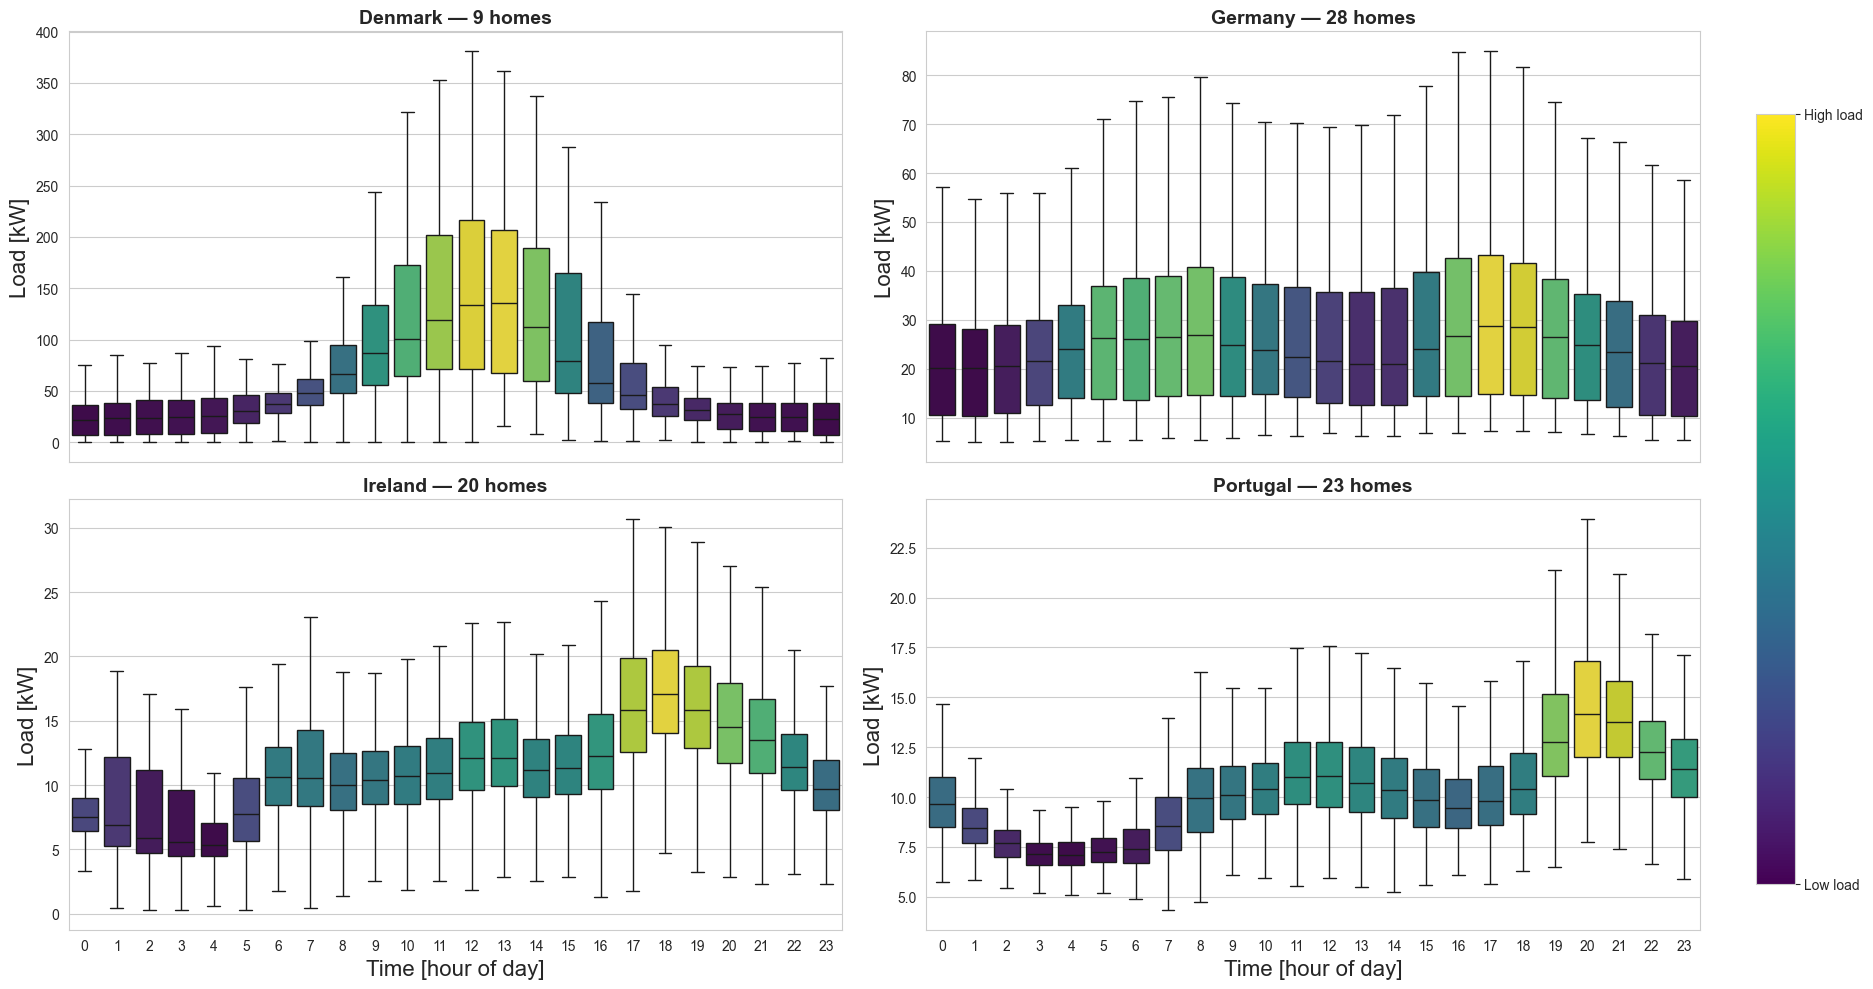

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

datasets = {
    "Denmark": read_dk,
    "Germany": read_de,
    "Ireland": read_ie,
    "Portugal": read_pt
}

sns.set_style("whitegrid")

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(20, 10),
    sharex=True
)

axes = axes.flatten()

for ax, (country, df) in zip(axes, datasets.items()):

    home_cols = [c for c in df.columns if c.startswith("home_")]
    print(f"{country}: {len(home_cols)} homes")

    total_load = df[home_cols].sum(axis=1)

    if country == "Denmark":
        total_load = total_load * 4      # kWh per 15 min -> kW
    else:
        total_load = total_load / 1000   # W -> kW


    plot_df = pd.DataFrame({
        "load": total_load,
        "hour": total_load.index.hour
    })

    hourly_median = plot_df.groupby("hour")["load"].median()

    norm = Normalize(
        vmin=hourly_median.min(),
        vmax=hourly_median.max()
    )

    palette = {
        hour: cm.viridis(norm(value))
        for hour, value in hourly_median.items()
    }

    sns.boxplot(
        data=plot_df,
        x="hour",
        y="load",
        hue="hour",
        palette=palette,
        ax=ax,
        showfliers=False,
        linewidth=1,
        legend=False
    )
    #ax.set_ylim(bottom=0) # Adjust y-axis to start at 0
    ax.set_title(f"{country} — {len(home_cols)} homes", fontsize=14, fontweight="bold")
    ax.set_xlabel("Time [hour of day]", fontsize=16)
    ax.set_ylabel("Load [kW]", fontsize=16)


# ============================================================
# SHARED VIRIDIS COLOR SCALE
# ============================================================
sm = ScalarMappable(
    cmap=cm.viridis,
    norm=Normalize(vmin=0, vmax=1)
)

sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=axes,
    orientation="vertical",
    fraction=0.025,
    pad=0.02
)

cbar.set_label("", fontsize=16)
cbar.set_ticks([0, 1])
cbar.set_ticklabels(["Low load", "High load"])

plt.tight_layout(rect=[0, 0, 0.86, 1])
output_path = r"C:\Users\Dimitrios\Desktop\AAU_ECforecasting\AAU_learning_to_predict_together_or_alone\Outputs\load_distribution_profiles.pdf"

plt.savefig(
    output_path,
    format="pdf",
    dpi=500,
    bbox_inches="tight"
)

plt.show()



# germany (units in watts)

Number of households: 28


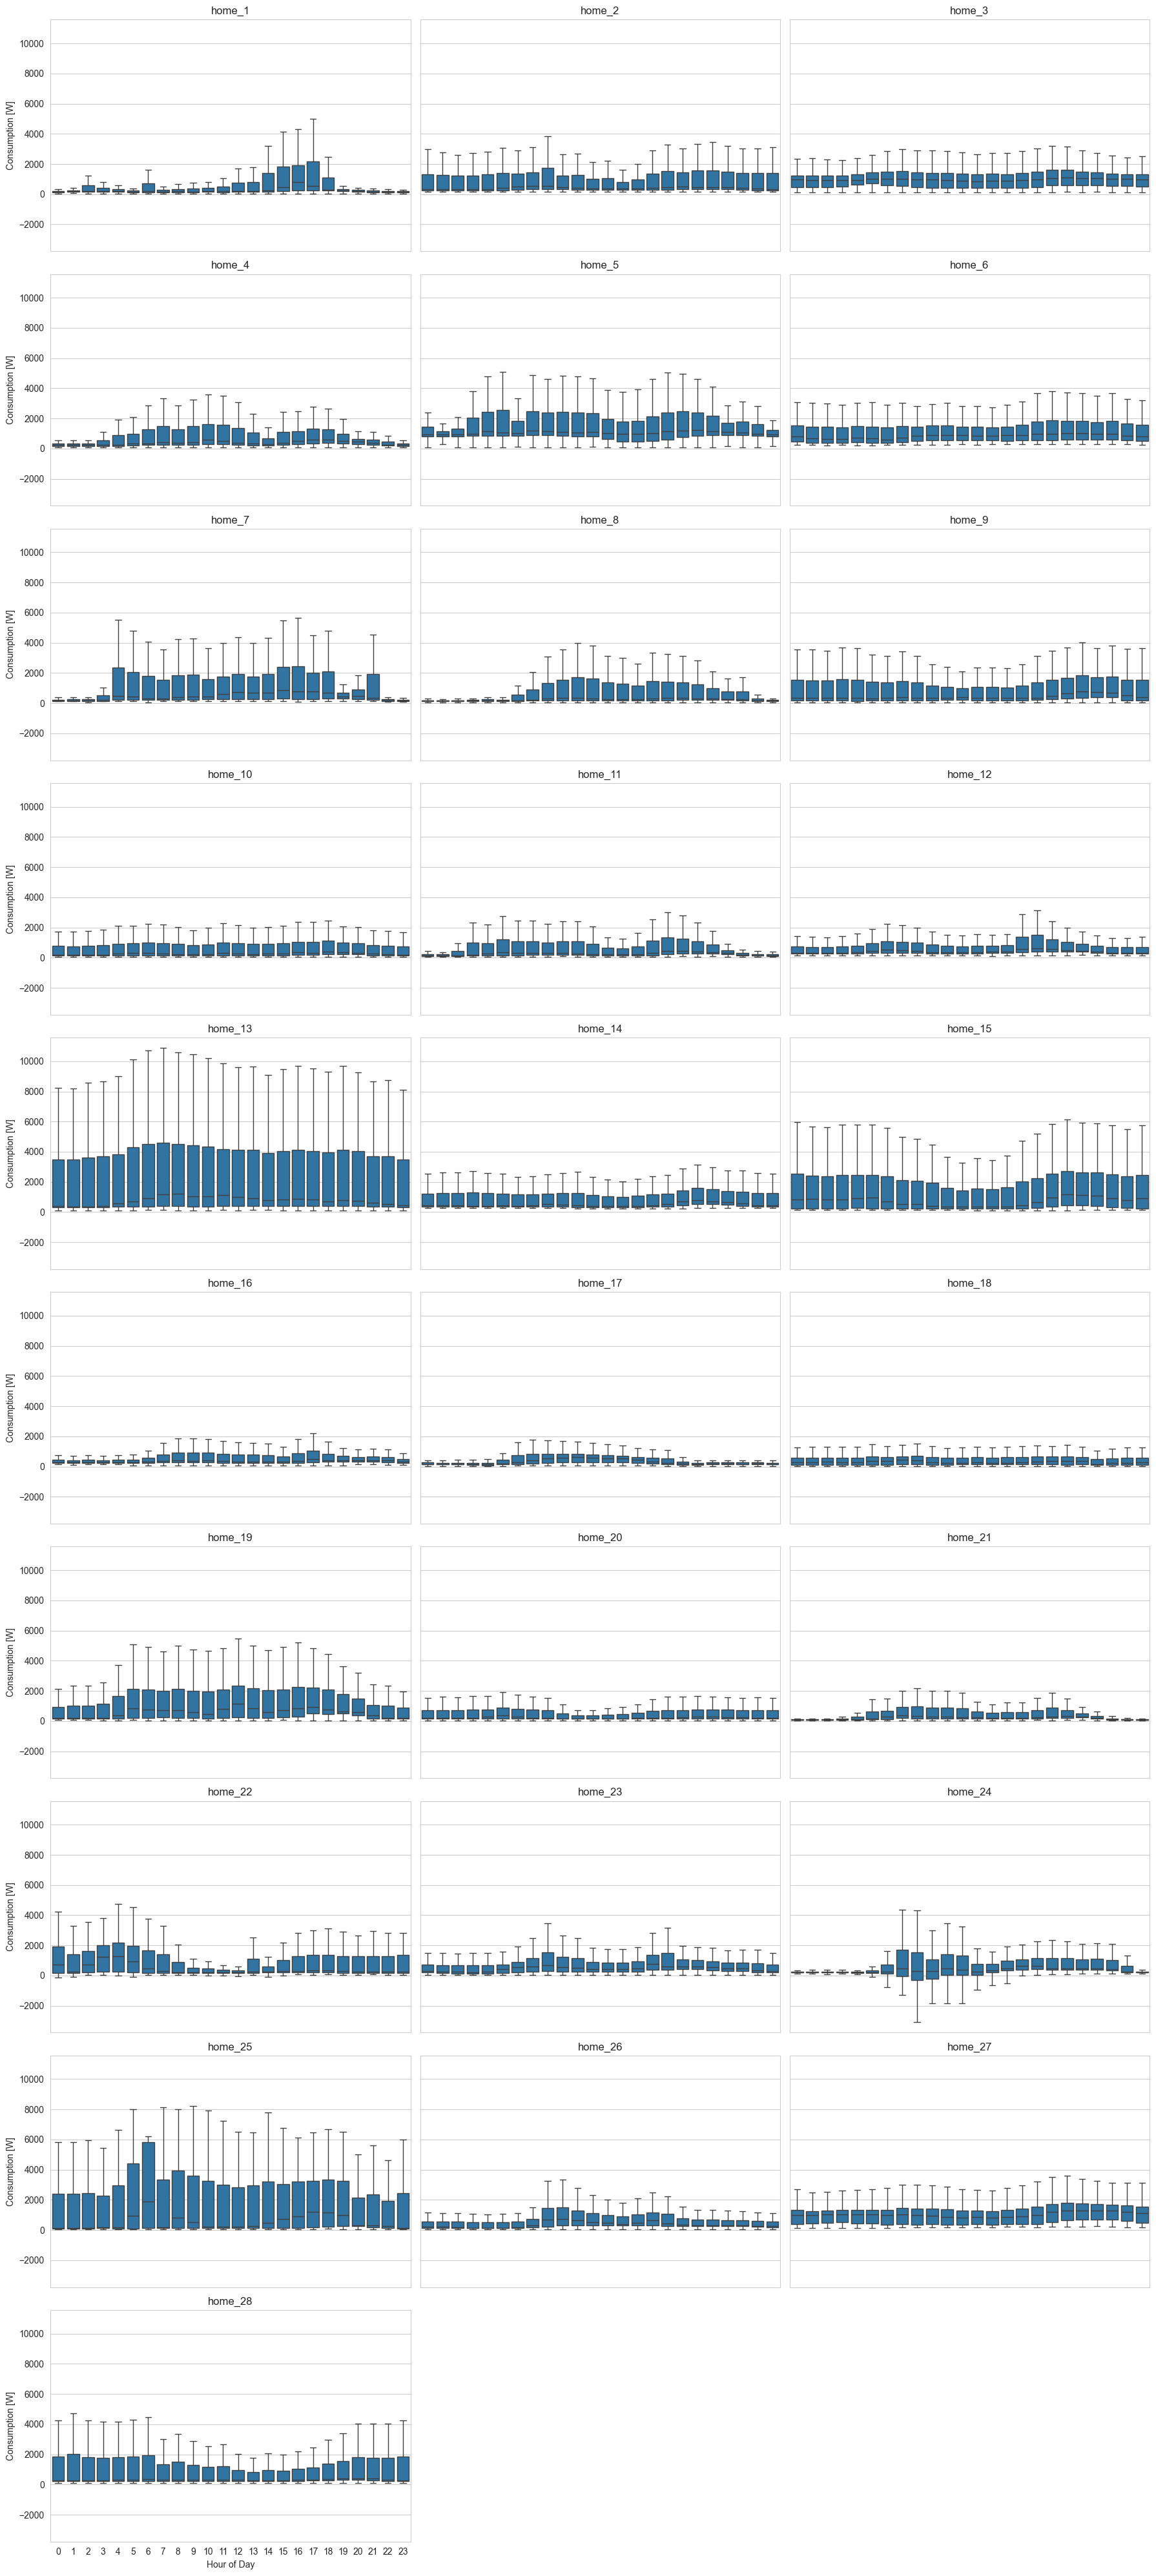

In [9]:
import math
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------
# Select household columns
# ---------------------------------------------------
house_cols = [col for col in read_de.columns if col.startswith("home_")]

# ---------------------------------------------------
# Count homes
# ---------------------------------------------------
n_homes = len(house_cols)

print(f"Number of households: {n_homes}")

# ---------------------------------------------------
# Dynamically create subplot grid
# ---------------------------------------------------
ncols = 3
nrows = math.ceil(n_homes / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(6 * ncols, 4 * nrows),
    sharex=True,
    sharey=True
)

# Make axes iterable even if only one row
axes = axes.flatten()

# ---------------------------------------------------
# Loop through each household
# ---------------------------------------------------
for i, home in enumerate(house_cols):

    # Resample (15-minute in your case)
    profile = read_de[[home]].resample("15min").sum()

    # Extract hour of day
    profile["hour"] = profile.index.hour

    # Distribution plot
    sns.boxplot(
        data=profile,
        x="hour",
        y=home,
        ax=axes[i],
        showfliers=False  # cleaner visualization
    )

    axes[i].set_title(home)
    axes[i].set_xlabel("Hour of Day")
    axes[i].set_ylabel("Consumption [W]")

# ---------------------------------------------------
# Remove empty subplots
# ---------------------------------------------------
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# ---------------------------------------------------
# Final layout
# ---------------------------------------------------
plt.tight_layout()
plt.show()

# ireland (units in watts)

Number of households: 20


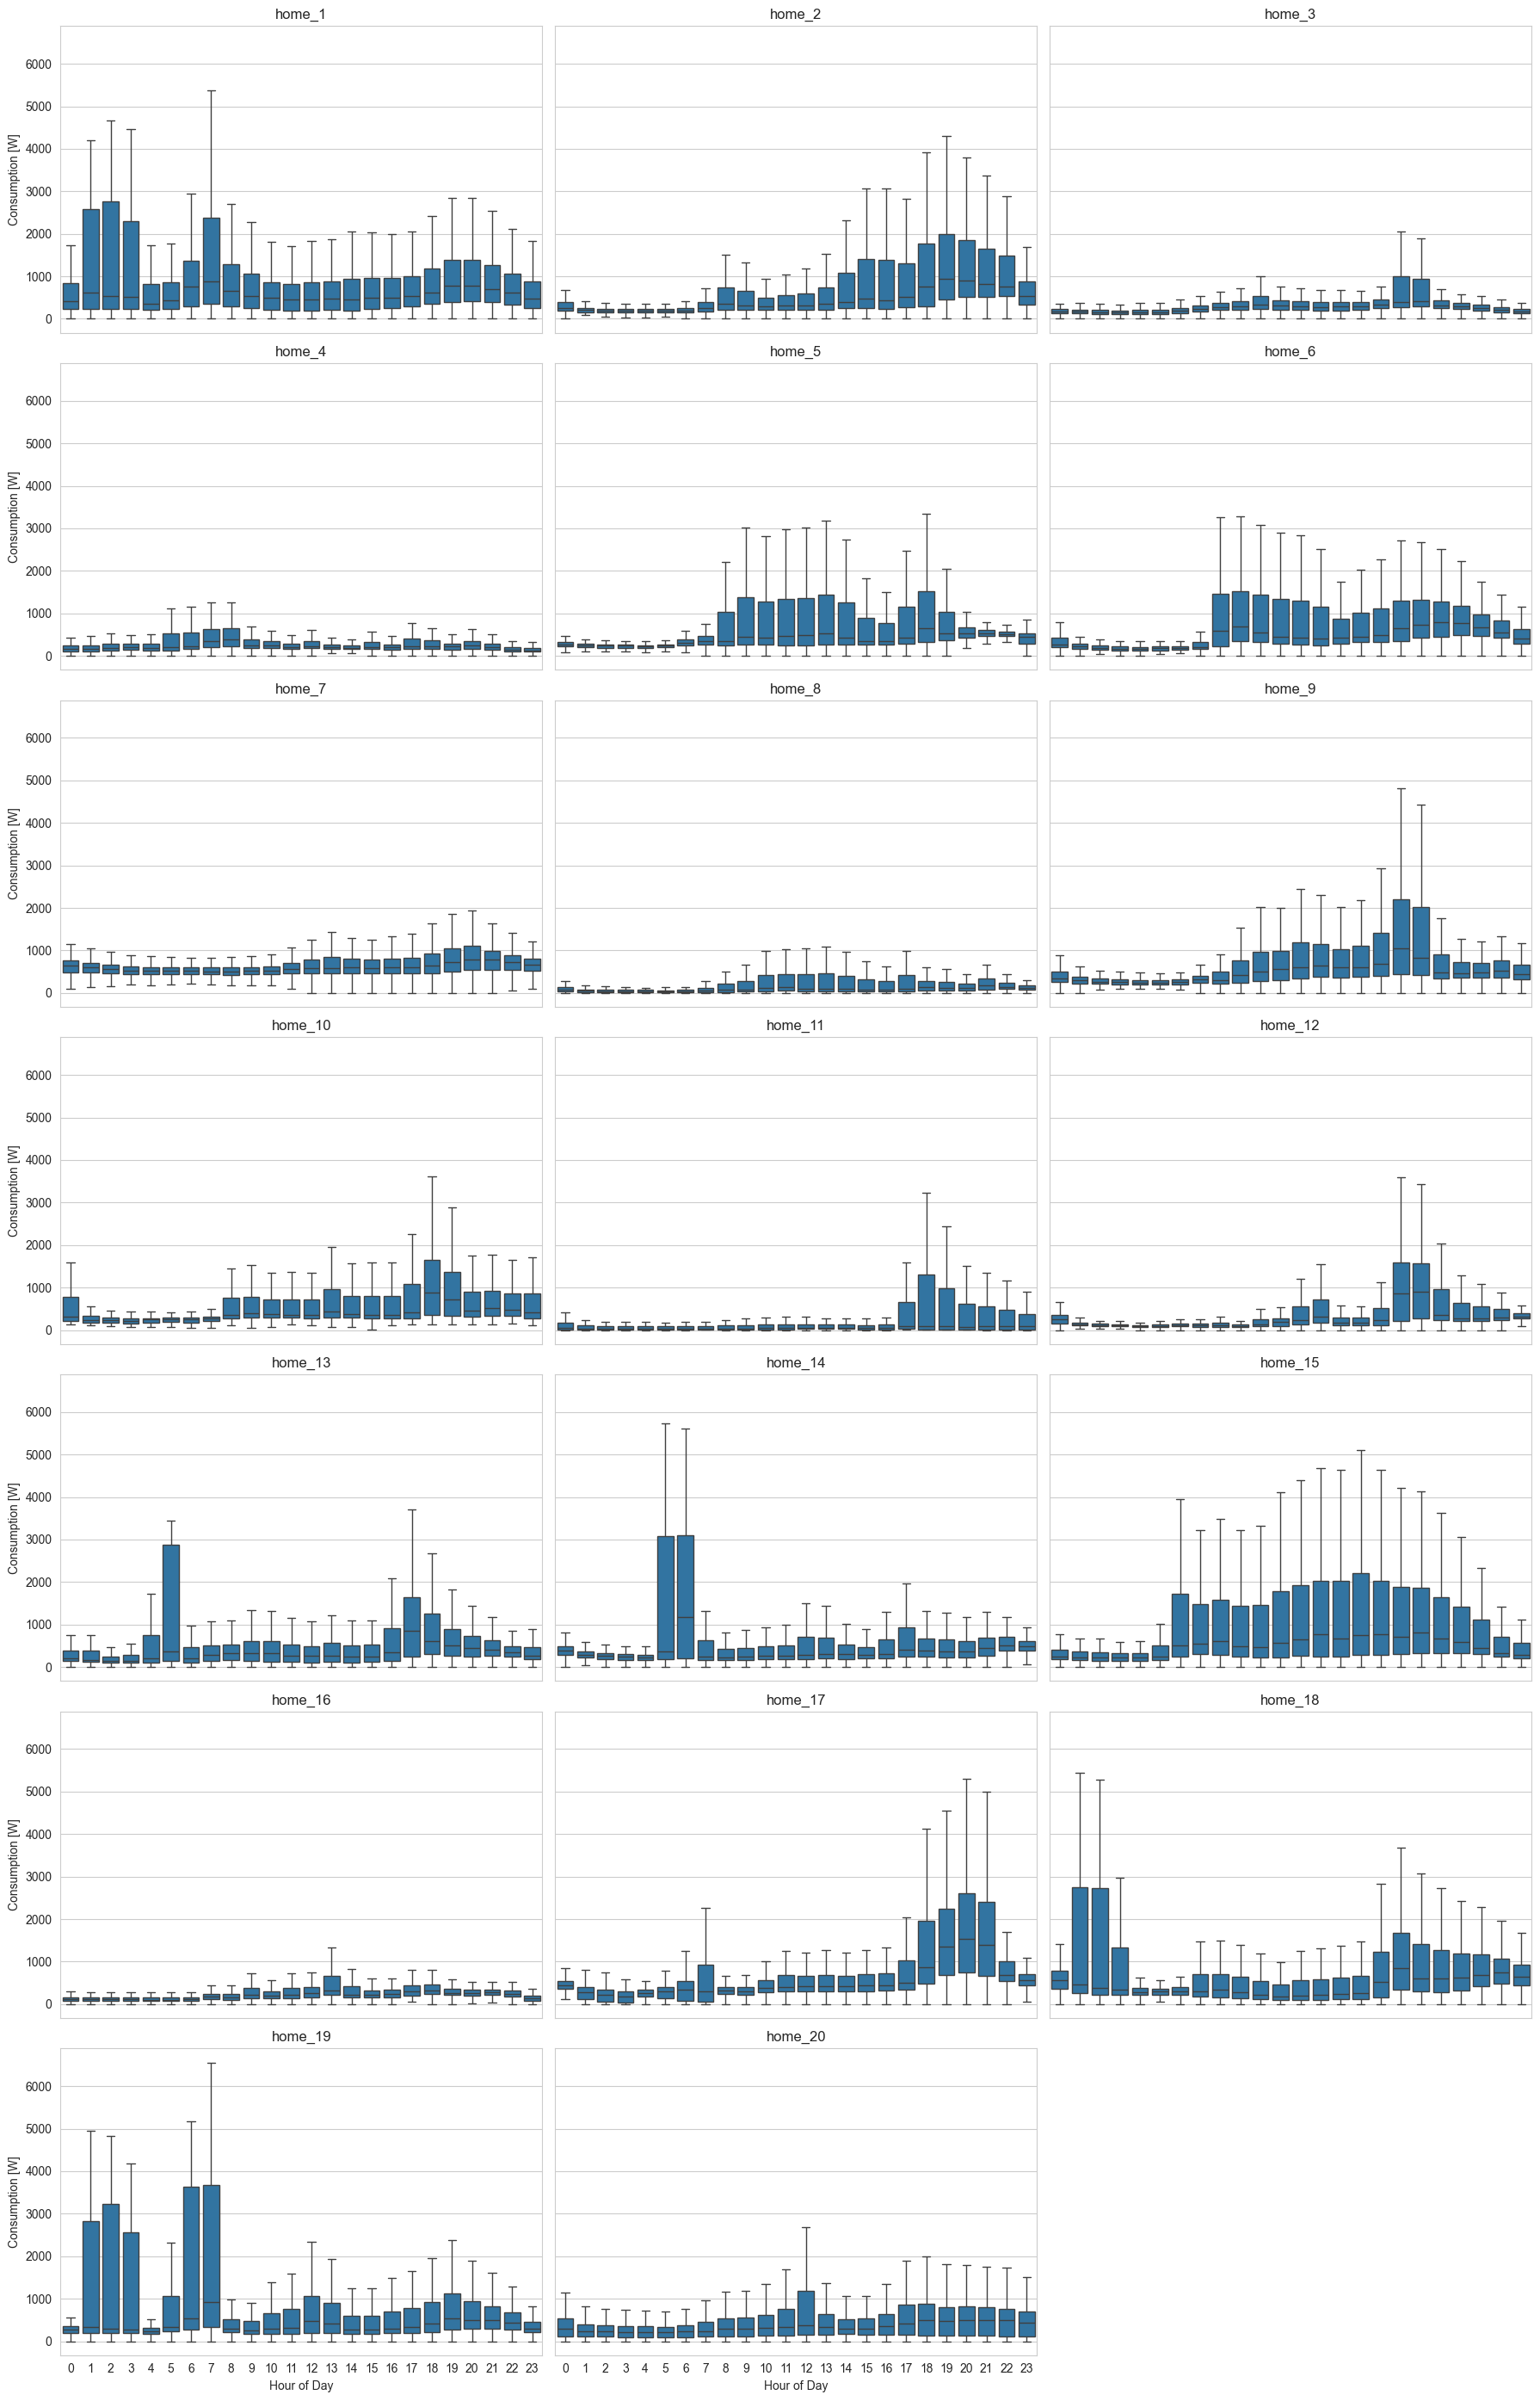

In [10]:
import math
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------
# Select household columns
# ---------------------------------------------------
house_cols = [col for col in read_ie.columns if col.startswith("home_")]

# ---------------------------------------------------
# Count homes
# ---------------------------------------------------
n_homes = len(house_cols)

print(f"Number of households: {n_homes}")

# ---------------------------------------------------
# Dynamically create subplot grid
# ---------------------------------------------------
ncols = 3
nrows = math.ceil(n_homes / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(6 * ncols, 4 * nrows),
    sharex=True,
    sharey=True
)

# Make axes iterable even if only one row
axes = axes.flatten()

# ---------------------------------------------------
# Loop through each household
# ---------------------------------------------------
for i, home in enumerate(house_cols):

    # Resample (15-minute in your case)
    profile = read_ie[[home]].resample("15min").sum()

    # Extract hour of day
    profile["hour"] = profile.index.hour

    # Distribution plot
    sns.boxplot(
        data=profile,
        x="hour",
        y=home,
        ax=axes[i],
        showfliers=False  # cleaner visualization
    )

    axes[i].set_title(home)
    axes[i].set_xlabel("Hour of Day")
    axes[i].set_ylabel("Consumption [W]")

# ---------------------------------------------------
# Remove empty subplots
# ---------------------------------------------------
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# ---------------------------------------------------
# Final layout
# ---------------------------------------------------
plt.tight_layout()
plt.show()

# portugal (units in Watts)

Number of households: 23


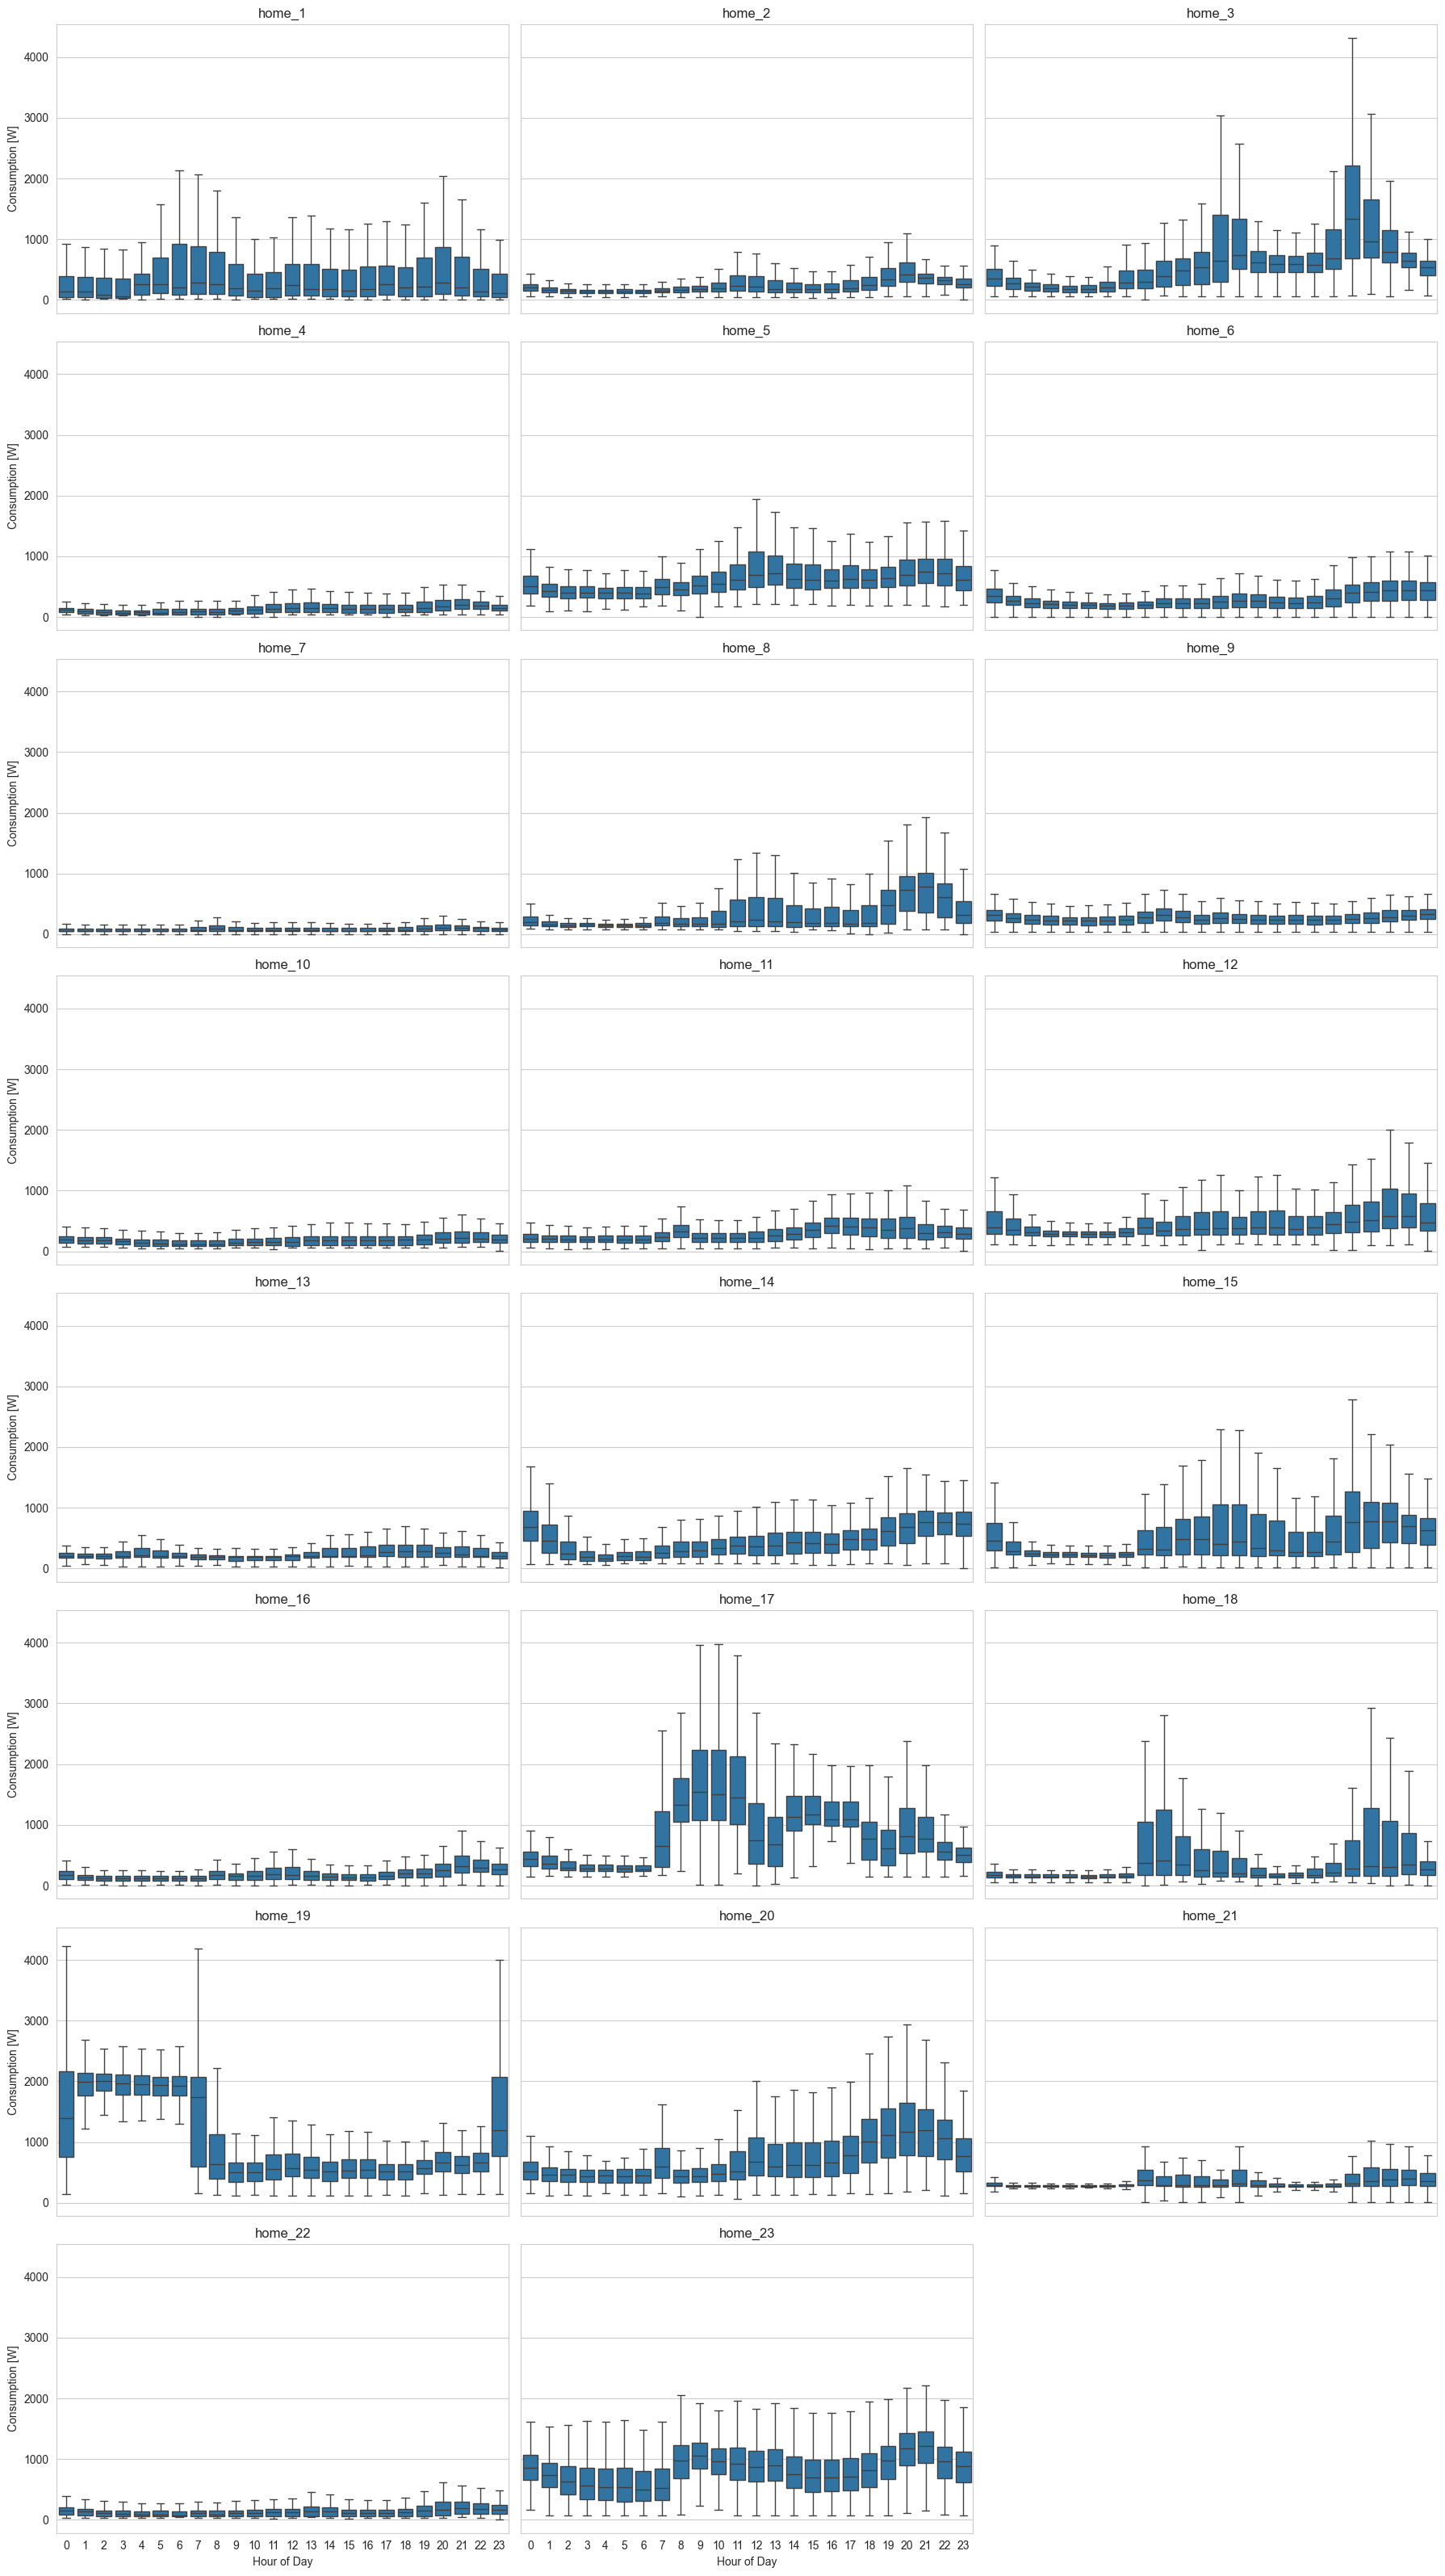

In [11]:
import math
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------
# Select household columns
# ---------------------------------------------------
house_cols = [col for col in read_pt.columns if col.startswith("home_")]

# ---------------------------------------------------
# Count homes
# ---------------------------------------------------
n_homes = len(house_cols)

print(f"Number of households: {n_homes}")

# ---------------------------------------------------
# Dynamically create subplot grid
# ---------------------------------------------------
ncols = 3
nrows = math.ceil(n_homes / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(6 * ncols, 4 * nrows),
    sharex=True,
    sharey=True
)

# Make axes iterable even if only one row
axes = axes.flatten()

# ---------------------------------------------------
# Loop through each household
# ---------------------------------------------------
for i, home in enumerate(house_cols):

    # Resample (15-minute in your case)
    profile = read_pt[[home]].resample("15min").sum()

    # Extract hour of day
    profile["hour"] = profile.index.hour

    # Distribution plot
    sns.boxplot(
        data=profile,
        x="hour",
        y=home,
        ax=axes[i],
        showfliers=False  # cleaner visualization
    )

    axes[i].set_title(home)
    axes[i].set_xlabel("Hour of Day")
    axes[i].set_ylabel("Consumption [W]")

# ---------------------------------------------------
# Remove empty subplots
# ---------------------------------------------------
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# ---------------------------------------------------
# Final layout
# ---------------------------------------------------
plt.tight_layout()
plt.show()

# denmark (units in kwh)

Number of households: 9


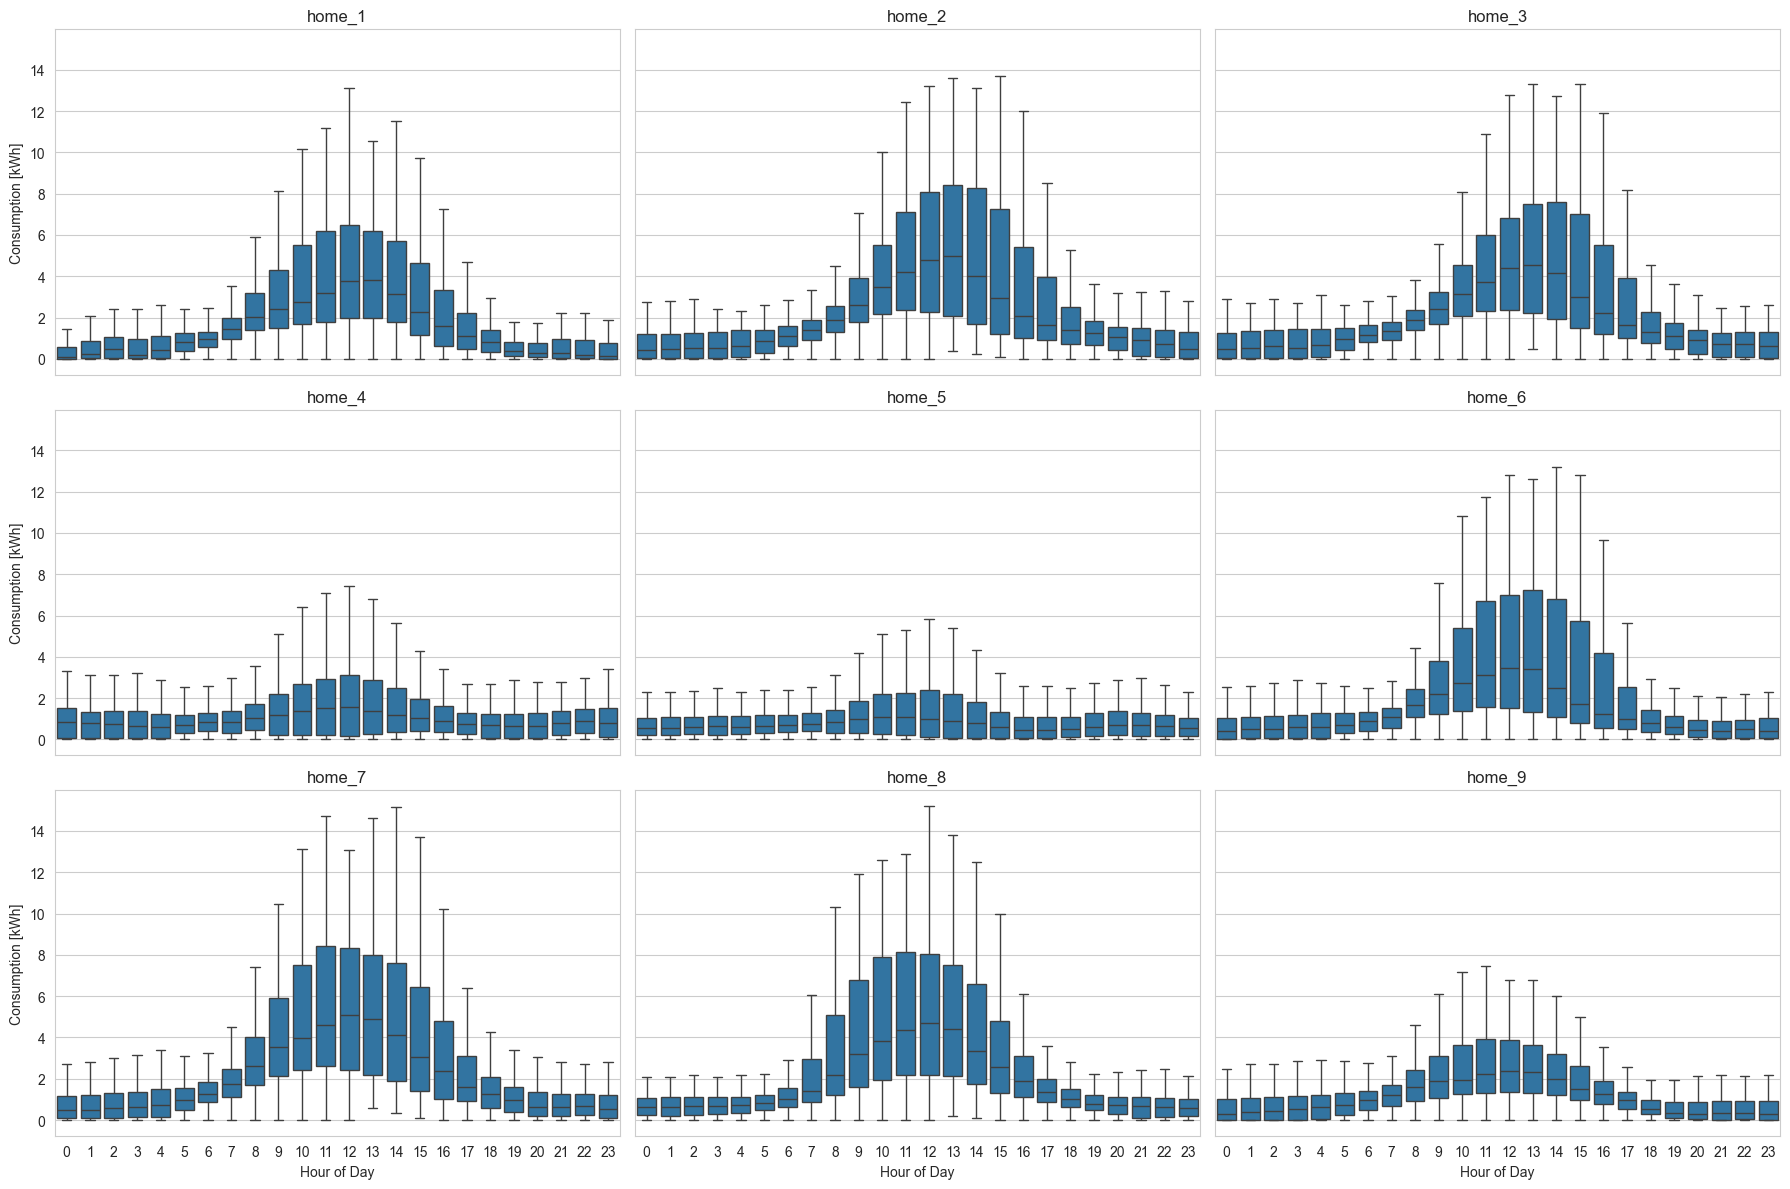

In [12]:
import math
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------
# Select household columns
# ---------------------------------------------------
house_cols = [col for col in read_dk.columns if col.startswith("home_")]

# ---------------------------------------------------
# Count homes
# ---------------------------------------------------
n_homes = len(house_cols)

print(f"Number of households: {n_homes}")

# ---------------------------------------------------
# Dynamically create subplot grid
# ---------------------------------------------------
ncols = 3
nrows = math.ceil(n_homes / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(6 * ncols, 4 * nrows),
    sharex=True,
    sharey=True
)

# Make axes iterable even if only one row
axes = axes.flatten()

# ---------------------------------------------------
# Loop through each household
# ---------------------------------------------------
for i, home in enumerate(house_cols):

    # Resample (15-minute in your case)
    profile = read_dk[[home]].resample("15min").sum()

    # Extract hour of day
    profile["hour"] = profile.index.hour

    # Distribution plot
    sns.boxplot(
        data=profile,
        x="hour",
        y=home,
        ax=axes[i],
        showfliers=False  # cleaner visualization
    )

    axes[i].set_title(home)
    axes[i].set_xlabel("Hour of Day")
    axes[i].set_ylabel("Consumption [kWh]")

# ---------------------------------------------------
# Remove empty subplots
# ---------------------------------------------------
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# ---------------------------------------------------
# Final layout
# ---------------------------------------------------
plt.tight_layout()
plt.show()

# Run this cell to print all the predictions

In [13]:
import pandas as pd
import numpy as np
import json
from pathlib import Path
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ============================================================
# PATHS
# ============================================================
project_root = Path(r"C:\Users\Dimitrios\Desktop\AAU_ECforecasting\AAU_learning_to_predict_together_or_alone")
base_folder = project_root / "Outputs"
data_clean_folder = project_root / "DataCleaning" / "clean"
days_json_path = project_root / "dataset_days.json"

# ============================================================
# SETTINGS
# ============================================================
countries = ["Denmark", "Germany", "Ireland", "Portugal"]
days = ["day1", "day2", "day3", "day4", "day5"]
steps_per_day = 96

# ============================================================
# METRICS
# ============================================================
def RMSE(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def MAE(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred)

def MBE(y_true, y_pred):
    return np.mean(y_pred - y_true)

def WAPE(y_true, y_pred):
    denom = np.sum(np.abs(y_true))
    if denom == 0:
        return np.nan
    return np.sum(np.abs(y_true - y_pred)) / denom

def get_quantile_threshold(y_true, q=0.95):
    return np.quantile(y_true, q)

def pRMSE(y_true, y_pred, quantile=0.95):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    threshold = get_quantile_threshold(y_true, quantile)
    mask = y_true > threshold

    if mask.sum() == 0:
        return np.nan

    return np.sqrt(mean_squared_error(y_true[mask], y_pred[mask]))

# ============================================================
# HELPERS
# ============================================================
def normalize_filename(s):
    return s.lower().replace("_", "").replace(" ", "").replace("-", "")

def weighted_average(values_dict, weights_dict):
    valid_items = [(k, v) for k, v in values_dict.items() if pd.notna(v) and k in weights_dict]
    if not valid_items:
        return np.nan

    vals = np.array([v for k, v in valid_items], dtype=float)
    w = np.array([weights_dict[k] for k, v in valid_items], dtype=float)

    if w.sum() == 0:
        return np.nan

    w = w / w.sum()
    return np.sum(vals * w)

def build_model_name(folder: Path):
    parent = folder.parent.name
    if parent in ["Global models", "Local models"]:
        return f"{parent} - {folder.name}"
    return folder.name

def collect_model_folders(base_folder: Path):
    all_model_folders = []

    for folder in base_folder.iterdir():
        if not folder.is_dir():
            continue

        if folder.name == "Selected_features":
            continue

        if folder.name in ["Global models", "Local models"]:
            for subfolder in folder.iterdir():
                if subfolder.is_dir():
                    all_model_folders.append(subfolder)
        else:
            all_model_folders.append(folder)

    return all_model_folders

def find_prediction_file(folder: Path, country: str, day: str):
    candidates = []
    country_norm = normalize_filename(country)
    day_norm = normalize_filename(day)

    for f in folder.glob("*.csv"):
        name = normalize_filename(f.name)
        if country_norm in name and day_norm in name:
            candidates.append(f)

    if len(candidates) == 0:
        print(f"[NOT FOUND] {build_model_name(folder)} | {country} | {day} -> no matching csv in: {folder}")
        return None

    if len(candidates) > 1:
        print(f"[MULTIPLE MATCHES] {build_model_name(folder)} | {country} | {day} -> using first match:")
        for c in candidates:
            print(f"   - {c.name}")

    return candidates[0]

def convert_units_to_kw(df: pd.DataFrame, country: str, home_cols):
    df = df.copy()

    if country == "Denmark":
        # Denmark: kWh per 15-min interval -> average kW
        df[home_cols] = df[home_cols] * 4
    else:
        # Other countries: W -> kW
        df[home_cols] = df[home_cols] / 1000

    return df



def detect_time_column(df):
    candidates = ["timestamp", "ds", "Datetime", "datetime", "time", "Time", "Unnamed: 0"]
    for c in candidates:
        if c in df.columns:
            return c
    return None

def detect_home_columns(df):
    return [c for c in df.columns if str(c).startswith("home_")]

def load_truth_for_country(country: str):
    truth_path = data_clean_folder / f"dataset_{country}.csv"
    if not truth_path.exists():
        print(f"[MISSING TRUTH FILE] {country} -> {truth_path}")
        return None, None, None, None

    df_true = pd.read_csv(truth_path)
    if "timestamp" not in df_true.columns:
        print(f"[INVALID TRUTH FILE] {country} -> no 'timestamp' column")
        return None, None, None, None

    df_true["timestamp"] = pd.to_datetime(df_true["timestamp"], errors="coerce")
    df_true = df_true.sort_values("timestamp").reset_index(drop=True)

    home_cols = detect_home_columns(df_true)
    if not home_cols:
        print(f"[INVALID TRUTH FILE] {country} -> no home_* columns")
        return None, None, None, None
    df_true = convert_units_to_kw(df_true, country, home_cols)

    house_energy = {h: df_true[h].abs().sum() for h in home_cols}
    total_energy = sum(house_energy.values())
    weights = {h: (house_energy[h] / total_energy if total_energy != 0 else np.nan) for h in home_cols}

    return df_true, home_cols, weights, house_energy

def load_day_map(days_json_path: Path):
    with open(days_json_path, "r", encoding="utf-8") as f:
        return json.load(f)


def build_naive_predictions(df_true, home_cols, country, day, day_map):
    target_date = pd.to_datetime(day_map[country][day]).date()

    prev_day = target_date - pd.Timedelta(days=1)
    week_start = target_date - pd.Timedelta(days=7)

    df_target = df_true[df_true["timestamp"].dt.date == target_date][["timestamp"] + home_cols].copy()
    df_prev = df_true[df_true["timestamp"].dt.date == prev_day][["timestamp"] + home_cols].copy()
    df_week = df_true[
        (df_true["timestamp"].dt.date >= week_start) &
        (df_true["timestamp"].dt.date < target_date)
    ][["timestamp"] + home_cols].copy()

    naive_preds = {}

    # 1. Previous day, same time
    if len(df_prev) == steps_per_day:
        pred_ld = df_target[["timestamp"]].copy()
        pred_ld[home_cols] = df_prev[home_cols].reset_index(drop=True).values
        naive_preds["Naive_LD"] = pred_ld

    # 2. Average value of previous day, repeated for all 96 steps
    if len(df_prev) == steps_per_day:
        pred_avg = df_target[["timestamp"]].copy()
        for h in home_cols:
            pred_avg[h] = df_prev[h].mean()
        naive_preds["Naive_AVG"] = pred_avg

    # 3. Average profile of previous 7 days
    if len(df_week) == steps_per_day * 7:
        df_week = df_week.copy()
        df_week["step"] = df_week.groupby(df_week["timestamp"].dt.date).cumcount()

        week_profile = df_week.groupby("step")[home_cols].mean()

        pred_weekavg = df_target[["timestamp"]].copy()
        pred_weekavg[home_cols] = week_profile.reset_index(drop=True).values

        naive_preds["Naive_WeekAVG"] = pred_weekavg

    return naive_preds



def get_truth_day_slice(df_true: pd.DataFrame, home_cols, country: str, day: str, day_map: dict):
    if country not in day_map:
        print(f"[DAY MAP ERROR] {country} not in dataset_days.json")
        return None

    if day not in day_map[country]:
        print(f"[DAY MAP ERROR] {country} | {day} not in dataset_days.json")
        return None

    target_date = pd.to_datetime(day_map[country][day]).date()

    df_day = df_true[df_true["timestamp"].dt.date == target_date][["timestamp"] + home_cols].copy()
    df_day = df_day.sort_values("timestamp").reset_index(drop=True)

    if len(df_day) == 0:
        print(f"[TRUTH SLICE ERROR] {country} | {day} -> no rows found for date {target_date}")
        return None

    if len(df_day) != steps_per_day:
        print(f"[TRUTH SLICE WARN] {country} | {day} -> expected {steps_per_day} rows, got {len(df_day)} for date {target_date}")

    return df_day

def save_weights(country: str, weights: dict, house_energy: dict):
    weights_df = pd.DataFrame({
        "Country": country,
        "Household": list(weights.keys()),
        "Weight": list(weights.values()),
        "Total_abs_load": [house_energy[h] for h in weights.keys()]
    }).sort_values("Household").reset_index(drop=True)

    out_path = base_folder / f"{country}_household_weights.csv"
    weights_df.to_csv(out_path, index=False)
    print(f"[SAVED] weights -> {out_path}")
    return weights_df

# ============================================================
# LOAD DAY MAP
# ============================================================
day_map = load_day_map(days_json_path)
print("Loaded dataset_days.json")

# ============================================================
# COLLECT ALL MODEL FOLDERS ONCE
# ============================================================
all_model_folders = collect_model_folders(base_folder)

print(f"\nTotal model folders detected: {len(all_model_folders)}")
for mf in all_model_folders:
    print(" -", build_model_name(mf))

# ============================================================
# MAIN LOOP OVER COUNTRIES AND DAYS
# ============================================================
all_results = []
all_per_house = []
all_weights_frames = []

for country in countries:
    print("\n" + "=" * 80)
    print(f"COUNTRY: {country}")
    print("=" * 80)

    df_true, home_cols, weights, house_energy = load_truth_for_country(country)

    if df_true is None:
        print(f"[SKIP COUNTRY] {country}")
        continue

    print(f"Truth home columns for {country}: {home_cols}")
    print(f"Truth shape for {country}: {df_true.shape}")
    print(f"Truth start: {df_true['timestamp'].min()}")
    print(f"Truth end:   {df_true['timestamp'].max()}")

    weights_df = save_weights(country, weights, house_energy)
    all_weights_frames.append(weights_df)

    for day in days:
        print("\n" + "-" * 80)
        print(f"Evaluating {country} | {day}")
        print("-" * 80)

        df_true_day = get_truth_day_slice(df_true, home_cols, country, day, day_map)

        if df_true_day is None or len(df_true_day) == 0:
            print(f"[SKIP] {country} | {day} -> invalid truth slice")
            continue

        print(f"Truth slice shape: {df_true_day.shape}")
        print(f"Truth day start: {df_true_day['timestamp'].min()}")
        print(f"Truth day end:   {df_true_day['timestamp'].max()}")

        results = []
        per_model_per_house_metrics = []


        # ========================================================
        # NAIVE BASELINES
        # ========================================================
        naive_predictions = build_naive_predictions(
            df_true=df_true,
            home_cols=home_cols,
            country=country,
            day=day,
            day_map=day_map
        )

        for model_name, df_pred in naive_predictions.items():

            print(f"\nEvaluating naive baseline: {model_name} | {country} | {day}")

            common_home_cols = home_cols.copy()

            df_eval = pd.merge(
                df_true_day[["timestamp"] + common_home_cols],
                df_pred[["timestamp"] + common_home_cols],
                on="timestamp",
                how="inner",
                suffixes=("_true", "_pred")
            )

            per_home_rmse = {}
            per_home_mae = {}
            per_home_mbe = {}
            per_home_wape = {}
            per_home_prmse = {}

            for h in common_home_cols:
                yt = pd.to_numeric(df_eval[f"{h}_true"], errors="coerce")
                yp = pd.to_numeric(df_eval[f"{h}_pred"], errors="coerce")

                mask = yt.notna() & yp.notna()
                yt = yt[mask]
                yp = yp[mask]

                if len(yt) == 0:
                    continue

                per_home_rmse[h] = RMSE(yt, yp)
                per_home_mae[h] = MAE(yt, yp)
                per_home_mbe[h] = MBE(yt, yp)
                per_home_wape[h] = WAPE(yt, yp)
                per_home_prmse[h] = pRMSE(yt, yp)

            for h in per_home_rmse.keys():
                per_model_per_house_metrics.append({
                    "Country": country,
                    "Day": day,
                    "TargetDate": day_map[country][day],
                    "Model": model_name,
                    "Household": h,
                    "Weight": weights.get(h, np.nan),
                    "RMSE": per_home_rmse.get(h, np.nan),
                    "MAE": per_home_mae.get(h, np.nan),
                    "MBE": per_home_mbe.get(h, np.nan),
                    "WAPE": per_home_wape.get(h, np.nan),
                    "pRMSE": per_home_prmse.get(h, np.nan),
                })

            if len(per_home_rmse) == 0:
                print(f"[SKIP] {model_name} | {country} | {day} -> no valid naive metrics")
                continue


            results.append({
                "Country": country,
                "Day": day,
                "TargetDate": day_map[country][day],
                "Model": model_name,

                "RMSE_mean": np.nanmean(list(per_home_rmse.values())),
                "MAE_mean": np.nanmean(list(per_home_mae.values())),
                "MBE_mean": np.nanmean(list(per_home_mbe.values())),
                "WAPE_mean": np.nanmean(list(per_home_wape.values())),
                "pRMSE_mean": np.nanmean(list(per_home_prmse.values())),

                "RMSE_weighted": weighted_average(per_home_rmse, weights),
                "MAE_weighted": weighted_average(per_home_mae, weights),
                "MBE_weighted": weighted_average(per_home_mbe, weights),
                "WAPE_weighted": weighted_average(per_home_wape, weights),
                "pRMSE_weighted": weighted_average(per_home_prmse, weights),

                "Homes_used": len(per_home_rmse),
            })


        for folder in all_model_folders:
            model_name = build_model_name(folder)
            file_path = find_prediction_file(folder, country, day)

            if file_path is None:
                continue

            print(f"\nEvaluating: {model_name} | {country} | {day}")
            print(f"Using file: {file_path.name}")

            try:
                df_pred = pd.read_csv(file_path)
            except Exception as e:
                print(f"[READ ERROR] {model_name} | {country} | {day} -> {e}")
                continue

            print("Prediction columns:", df_pred.columns.tolist())

            time_col = detect_time_column(df_pred)
            if time_col is None:
                print(f"[SKIP] {model_name} | {country} | {day} -> no recognizable time column")
                continue

            pred_home_cols = detect_home_columns(df_pred)
            if not pred_home_cols:
                print(f"[SKIP] {model_name} | {country} | {day} -> no home_* columns")
                continue

            df_pred = convert_units_to_kw(df_pred, country, pred_home_cols)
            print(f"[UNIT CHECK] {country} | {model_name} | {day}")
            print(df_pred[pred_home_cols].describe().loc[["min", "mean", "max"]])
            
            df_pred = df_pred.copy()
            df_pred = df_pred.rename(columns={time_col: "timestamp"})
            df_pred["timestamp"] = pd.to_datetime(df_pred["timestamp"], errors="coerce")
            df_pred = df_pred.sort_values("timestamp").reset_index(drop=True)

            if df_pred["timestamp"].isna().all():
                print(f"[SKIP] {model_name} | {country} | {day} -> time column could not be parsed")
                continue

            common_home_cols = [c for c in home_cols if c in df_pred.columns]
            if not common_home_cols:
                print(f"[SKIP] {model_name} | {country} | {day} -> no common home columns with truth")
                continue

            print(f"[INFO] detected time column: {time_col}")
            print(f"Pred start: {df_pred['timestamp'].min()}")
            print(f"Pred end:   {df_pred['timestamp'].max()}")

            # --------------------------------------------------------
            # CASE 1: exact timestamp merge
            # --------------------------------------------------------
            df_eval = pd.merge(
                df_true_day[["timestamp"] + common_home_cols],
                df_pred[["timestamp"] + common_home_cols],
                on="timestamp",
                how="inner",
                suffixes=("_true", "_pred")
            )

            use_rowwise = False
            if df_eval.empty:
                print(f"[INFO] {model_name} | {country} | {day} -> timestamp merge failed, using row-wise alignment")
                use_rowwise = True

            per_home_rmse = {}
            per_home_mae = {}
            per_home_mbe = {}
            per_home_wape = {}
            per_home_prmse = {}

            try:
                if use_rowwise:
                    n = min(len(df_true_day), len(df_pred))
                    if n == 0:
                        print(f"[SKIP] {model_name} | {country} | {day} -> no rows available for row-wise alignment")
                        continue

                    df_true_aligned = df_true_day.iloc[:n].copy().reset_index(drop=True)
                    df_pred_aligned = df_pred.iloc[:n].copy().reset_index(drop=True)

                    for h in common_home_cols:
                        yt = pd.to_numeric(df_true_aligned[h], errors="coerce")
                        yp = pd.to_numeric(df_pred_aligned[h], errors="coerce")

                        mask = yt.notna() & yp.notna()
                        yt = yt[mask]
                        yp = yp[mask]

                        if len(yt) == 0:
                            print(f"[WARN] {model_name} | {country} | {day} -> {h} has no valid aligned values")
                            continue

                        per_home_rmse[h] = RMSE(yt, yp)
                        per_home_mae[h] = MAE(yt, yp)
                        per_home_mbe[h] = MBE(yt, yp)
                        per_home_wape[h] = WAPE(yt, yp)
                        per_home_prmse[h] = pRMSE(yt, yp)

                else:
                    for h in common_home_cols:
                        yt = pd.to_numeric(df_eval[f"{h}_true"], errors="coerce")
                        yp = pd.to_numeric(df_eval[f"{h}_pred"], errors="coerce")

                        mask = yt.notna() & yp.notna()
                        yt = yt[mask]
                        yp = yp[mask]

                        if len(yt) == 0:
                            print(f"[WARN] {model_name} | {country} | {day} -> {h} has no valid merged values")
                            continue

                        per_home_rmse[h] = RMSE(yt, yp)
                        per_home_mae[h] = MAE(yt, yp)
                        per_home_mbe[h] = MBE(yt, yp)
                        per_home_wape[h] = WAPE(yt, yp)
                        per_home_prmse[h] = pRMSE(yt, yp)

            except Exception as e:
                print(f"[EVAL ERROR] {model_name} | {country} | {day} -> {e}")
                continue

            if len(per_home_rmse) == 0:
                print(f"[SKIP] {model_name} | {country} | {day} -> no valid household metrics could be computed")
                continue

            for h in per_home_rmse.keys():
                per_model_per_house_metrics.append({
                    "Country": country,
                    "Day": day,
                    "TargetDate": day_map[country][day],
                    "Model": model_name,
                    "Household": h,
                    "Weight": weights.get(h, np.nan),
                    "RMSE": per_home_rmse.get(h, np.nan),
                    "MAE": per_home_mae.get(h, np.nan),
                    "MBE": per_home_mbe.get(h, np.nan),
                    "WAPE": per_home_wape.get(h, np.nan),
                    "pRMSE": per_home_prmse.get(h, np.nan),
                })


            mean_rmse = np.nanmean(list(per_home_rmse.values()))
            mean_mae = np.nanmean(list(per_home_mae.values()))
            mean_mbe = np.nanmean(list(per_home_mbe.values()))
            mean_wape = np.nanmean(list(per_home_wape.values()))
            mean_prmse = np.nanmean(list(per_home_prmse.values()))

            weighted_rmse = weighted_average(per_home_rmse, weights)
            weighted_mae = weighted_average(per_home_mae, weights)
            weighted_mbe = weighted_average(per_home_mbe, weights)
            weighted_wape = weighted_average(per_home_wape, weights)
            weighted_prmse = weighted_average(per_home_prmse, weights)

            results.append({
                "Country": country,
                "Day": day,
                "TargetDate": day_map[country][day],
                "Model": model_name,

                "RMSE_mean": mean_rmse,
                "MAE_mean": mean_mae,
                "MBE_mean": mean_mbe,
                "WAPE_mean": mean_wape,
                "pRMSE_mean": mean_prmse,

                "RMSE_weighted": weighted_rmse,
                "MAE_weighted": weighted_mae,
                "MBE_weighted": weighted_mbe,
                "WAPE_weighted": weighted_wape,
                "pRMSE_weighted": weighted_prmse,

                "Homes_used": len(per_home_rmse),
            })

        # --------------------------------------------------------
        # SAVE COUNTRY-DAY FILES
        # --------------------------------------------------------
        if len(results) > 0:
            df_results = pd.DataFrame(results).sort_values("RMSE_mean").reset_index(drop=True)

            summary_out = base_folder / f"{country}_{day}_model_comparison_mean_weighted_all_models.csv"
            df_results.to_csv(summary_out, index=False)
            print(f"[SAVED] summary -> {summary_out}")

            all_results.append(df_results)
        else:
            print(f"[INFO] No summary results for {country} | {day}")

        if len(per_model_per_house_metrics) > 0:
            df_per_house = pd.DataFrame(per_model_per_house_metrics)

            per_house_out = base_folder / f"{country}_{day}_model_comparison_per_household_all_models.csv"
            df_per_house.to_csv(per_house_out, index=False)
            print(f"[SAVED] per-household -> {per_house_out}")

            all_per_house.append(df_per_house)
        else:
            print(f"[INFO] No per-household results for {country} | {day}")

# ============================================================
# SAVE COMBINED FILES
# ============================================================
print("\n" + "=" * 80)
print("SAVING COMBINED FILES")
print("=" * 80)

if len(all_weights_frames) > 0:
    df_all_weights = pd.concat(all_weights_frames, ignore_index=True)
    all_weights_out = base_folder / "ALL_COUNTRIES_household_weights.csv"
    df_all_weights.to_csv(all_weights_out, index=False)
    print(f"[SAVED] combined weights -> {all_weights_out}")

if len(all_results) > 0:
    df_all_results = pd.concat(all_results, ignore_index=True)
    df_all_results = df_all_results.sort_values(["Country", "Day", "RMSE_mean"]).reset_index(drop=True)

    all_results_out = base_folder / "ALL_COUNTRIES_ALL_DAYS_model_comparison_mean_weighted_all_models.csv"
    df_all_results.to_csv(all_results_out, index=False)
    print(f"[SAVED] combined summary -> {all_results_out}")

    print("\nCombined summary preview:")
    print(df_all_results.head())

else:
    print("[INFO] No combined summary results produced.")

if len(all_per_house) > 0:
    df_all_per_house = pd.concat(all_per_house, ignore_index=True)
    df_all_per_house = df_all_per_house.sort_values(["Country", "Day", "Model", "Household"]).reset_index(drop=True)

    all_per_house_out = base_folder / "ALL_COUNTRIES_ALL_DAYS_model_comparison_per_household_all_models.csv"
    df_all_per_house.to_csv(all_per_house_out, index=False)
    print(f"[SAVED] combined per-household -> {all_per_house_out}")

else:
    print("[INFO] No combined per-household results produced.")

Loaded dataset_days.json

Total model folders detected: 39
 - Chronos2_crosslearning
 - Chronos2_Univar
 - Chronos_bolt_base
 - Chronos_t5large
 - Global models - CatBoost
 - Global models - DT
 - Global models - ElasticNet
 - Global models - ET
 - Global models - GRU
 - Global models - KAN
 - Global models - Lasso
 - Global models - LGBM
 - Global models - LSTM
 - Global models - MLP
 - Global models - NBEATSx
 - Global models - NHITS
 - Global models - PatchTST
 - Global models - RF
 - Global models - Ridge
 - Global models - SVR
 - Global models - TCN
 - Global models - TiDE
 - Global models - TSMixerx
 - Global models - XGB
 - LagLlama
 - Local models - ElasticNet
 - Local models - Lasso
 - Local models - LGBM
 - Local models - RF
 - Local models - Ridge
 - Local models - XGBoost
 - Moirai1_large
 - Moirai2
 - MoiraiMoE_base
 - Moment
 - TabPFN
 - Timer
 - TimesFM
 - TiRex

COUNTRY: Denmark
Truth home columns for Denmark: ['home_1', 'home_2', 'home_3', 'home_4', 'home_5', 'home_6',

# calculate the cross validation of each country

In [14]:
import pandas as pd
from pathlib import Path

# ============================================================
# PATHS
# ============================================================
base_folder = Path(r"C:\Users\Dimitrios\Desktop\AAU_ECforecasting\AAU_learning_to_predict_together_or_alone\Outputs")

# ============================================================
# SETTINGS
# ============================================================
countries = ["Denmark", "Germany", "Ireland", "Portugal"]
days = ["day1", "day2", "day3", "day4", "day5"]

# metrics to average across folds
metric_cols = [
    "RMSE_mean",
    "MAE_mean",
    "MBE_mean",
    "WAPE_mean",
    "pRMSE_mean",
    "RMSE_weighted",
    "MAE_weighted",
    "MBE_weighted",
    "WAPE_weighted",
    "pRMSE_weighted",
    "Homes_used",
]

# ============================================================
# MAIN LOOP
# ============================================================
all_country_cv_results = []

for country in countries:
    print("\n" + "=" * 80)
    print(f"Processing country: {country}")
    print("=" * 80)

    country_day_frames = []

    for day in days:
        file_path = base_folder / f"{country}_{day}_model_comparison_mean_weighted_all_models.csv"

        if not file_path.exists():
            print(f"[MISSING] {file_path}")
            continue

        print(f"[READING] {file_path.name}")
        df_day = pd.read_csv(file_path)


Processing country: Denmark
[READING] Denmark_day1_model_comparison_mean_weighted_all_models.csv
[READING] Denmark_day2_model_comparison_mean_weighted_all_models.csv
[READING] Denmark_day3_model_comparison_mean_weighted_all_models.csv
[READING] Denmark_day4_model_comparison_mean_weighted_all_models.csv
[READING] Denmark_day5_model_comparison_mean_weighted_all_models.csv

Processing country: Germany
[READING] Germany_day1_model_comparison_mean_weighted_all_models.csv
[READING] Germany_day2_model_comparison_mean_weighted_all_models.csv
[READING] Germany_day3_model_comparison_mean_weighted_all_models.csv
[READING] Germany_day4_model_comparison_mean_weighted_all_models.csv
[READING] Germany_day5_model_comparison_mean_weighted_all_models.csv

Processing country: Ireland
[READING] Ireland_day1_model_comparison_mean_weighted_all_models.csv
[READING] Ireland_day2_model_comparison_mean_weighted_all_models.csv
[READING] Ireland_day3_model_comparison_mean_weighted_all_models.csv
[READING] Irelan

In [16]:
import pandas as pd
from pathlib import Path

# ============================================================
# PATHS
# ============================================================
base_folder = Path(r"C:\Users\Dimitrios\Desktop\AAU_ECforecasting\AAU_learning_to_predict_together_or_alone\Outputs")

# ============================================================
# SETTINGS
# ============================================================
countries = ["Denmark", "Germany", "Ireland", "Portugal"]
days = ["day1", "day2", "day3", "day4", "day5"]

# metrics to average across folds
metric_cols = [
    "RMSE_mean",
    "MAE_mean",
    "MBE_mean",
    "WAPE_mean",
    "pRMSE_mean",
    "RMSE_weighted",
    "MAE_weighted",
    "MBE_weighted",
    "WAPE_weighted",
    "pRMSE_weighted",
    "Homes_used",
]

# ============================================================
# MAIN LOOP
# ============================================================
all_country_cv_results = []

for country in countries:
    print("\n" + "=" * 80)
    print(f"Processing country: {country}")
    print("=" * 80)

    country_day_frames = []

    for day in days:
        file_path = base_folder / f"{country}_{day}_model_comparison_mean_weighted_all_models.csv"

        if not file_path.exists():
            print(f"[MISSING] {file_path}")
            continue

        print(f"[READING] {file_path.name}")
        df_day = pd.read_csv(file_path)

        # keep only relevant columns if present
        keep_cols = ["Model"] + [c for c in metric_cols if c in df_day.columns]
        df_day = df_day[keep_cols].copy()
        df_day["Day"] = day

        country_day_frames.append(df_day)

    if len(country_day_frames) == 0:
        print(f"[SKIP] No day files found for {country}")
        continue

    # concatenate 5 folds/days
    df_country_all_days = pd.concat(country_day_frames, ignore_index=True)

    # --------------------------------------------------------
    # Cross-validation average per model
    # --------------------------------------------------------
    agg_dict = {col: "mean" for col in metric_cols if col in df_country_all_days.columns}
    df_country_cv = (
        df_country_all_days
        .groupby("Model", as_index=False)
        .agg(agg_dict)
    )

    # count how many folds each model actually appeared in
    df_folds_used = (
        df_country_all_days
        .groupby("Model", as_index=False)
        .size()
        .rename(columns={"size": "Folds_used"})
    )

    df_country_cv = df_country_cv.merge(df_folds_used, on="Model", how="left")

    # sort by RMSE_mean if available
    if "RMSE_mean" in df_country_cv.columns:
        df_country_cv = df_country_cv.sort_values("RMSE_mean").reset_index(drop=True)

    # save per-country CV summary
    out_path = base_folder / f"{country}_cross_validation_mean_weighted_all_models.csv"
    df_country_cv.to_csv(out_path, index=False)
    print(f"[SAVED] {out_path}")

    all_country_cv_results.append(df_country_cv.assign(Country=country))

# ============================================================
# OPTIONAL: SAVE ALL COUNTRIES TOGETHER
# ============================================================
if len(all_country_cv_results) > 0:
    df_all_cv = pd.concat(all_country_cv_results, ignore_index=True)

    # reorder columns
    cols = ["Country", "Model"] + [c for c in df_all_cv.columns if c not in ["Country", "Model"]]
    df_all_cv = df_all_cv[cols]

    out_all = base_folder / "ALL_COUNTRIES_cross_validation_mean_weighted_all_models.csv"
    df_all_cv.to_csv(out_all, index=False)
    print("\n" + "=" * 80)
    print(f"[SAVED] combined CV file -> {out_all}")
else:
    print("\n[INFO] No country-level CV results were created.")


Processing country: Denmark
[READING] Denmark_day1_model_comparison_mean_weighted_all_models.csv
[READING] Denmark_day2_model_comparison_mean_weighted_all_models.csv
[READING] Denmark_day3_model_comparison_mean_weighted_all_models.csv
[READING] Denmark_day4_model_comparison_mean_weighted_all_models.csv
[READING] Denmark_day5_model_comparison_mean_weighted_all_models.csv
[SAVED] C:\Users\Dimitrios\Desktop\AAU_ECforecasting\AAU_learning_to_predict_together_or_alone\Outputs\Denmark_cross_validation_mean_weighted_all_models.csv

Processing country: Germany
[READING] Germany_day1_model_comparison_mean_weighted_all_models.csv
[READING] Germany_day2_model_comparison_mean_weighted_all_models.csv
[READING] Germany_day3_model_comparison_mean_weighted_all_models.csv
[READING] Germany_day4_model_comparison_mean_weighted_all_models.csv
[READING] Germany_day5_model_comparison_mean_weighted_all_models.csv
[SAVED] C:\Users\Dimitrios\Desktop\AAU_ECforecasting\AAU_learning_to_predict_together_or_alone\

# Checkpoint - lets inspect some countries

In [17]:
import pandas as pd
from pathlib import Path

# path
file_path = Path(r"C:\Users\Dimitrios\Desktop\AAU_ECforecasting\AAU_learning_to_predict_together_or_alone\Outputs\Portugal_cross_validation_mean_weighted_all_models.csv")

# read
df_portugal = pd.read_csv(file_path)

# sort (just to be sure)
df_portugal = df_portugal.reset_index(drop=True)


In [18]:
def highlight_best(s, is_mbe=False):
    if is_mbe:
        best = s.abs().min()
        return ['background-color: red' if abs(v) == best else '' for v in s]
    else:
        best = s.min()
        return ['background-color: red' if v == best else '' for v in s]

styled_portugal = (
    df_portugal.style
    .apply(lambda s: highlight_best(s), subset=[
        "RMSE_mean", "MAE_mean", "WAPE_mean", "pRMSE_mean",
        "RMSE_weighted", "MAE_weighted", "WAPE_weighted", "pRMSE_weighted"
    ], axis=0)
    .apply(lambda s: highlight_best(s, is_mbe=True), subset=[
        "MBE_mean", "MBE_weighted"
    ], axis=0)
)

styled_portugal

,Model,RMSE_mean,MAE_mean,MBE_mean,WAPE_mean,pRMSE_mean,RMSE_weighted,MAE_weighted,MBE_weighted,WAPE_weighted,pRMSE_weighted,Homes_used,Folds_used
0,Chronos2_crosslearning,0.285152,0.172853,-0.057222,0.442369,0.852579,0.350788,0.216881,-0.062094,0.405070,1.017347,23.000000,5
1,Chronos2_Univar,0.287043,0.175065,-0.049187,0.450756,0.843761,0.353469,0.220091,-0.053202,0.413729,1.008189,23.000000,5
2,TimesFM,0.288451,0.177406,-0.055645,0.451829,0.847666,0.355715,0.223683,-0.059190,0.419945,1.009176,23.000000,5
3,Chronos_bolt_base,0.288601,0.178209,-0.060337,0.450759,0.864013,0.355884,0.223840,-0.065597,0.416719,1.029684,23.000000,5
4,TiRex,0.290290,0.176718,-0.060230,0.444663,0.865562,0.356755,0.221334,-0.067048,0.410914,1.037183,23.000000,5
5,TabPFN,0.290960,0.182519,-0.029785,0.478164,0.833585,0.361072,0.230857,-0.028604,0.435594,0.997621,23.000000,5
6,Global models - ET,0.292606,0.195141,0.010556,0.537543,0.804280,0.356500,0.239987,0.007997,0.481345,0.970048,23.000000,5
7,Global models - CatBoost,0.295571,0.196678,0.009825,0.561063,0.804201,0.362203,0.243536,0.007714,0.496711,0.970062,23.000000,5
8,Moirai2,0.296842,0.187603,-0.056875,0.463788,0.867543,0.365082,0.234663,-0.061541,0.431109,1.033646,23.000000,5
9,Global models - RF,0.297037,0.198993,0.014481,0.540866,0.803820,0.365551,0.247865,0.016565,0.492089,0.967886,23.000000,5


In [19]:
# path
file_path = Path(r"C:\Users\Dimitrios\Desktop\AAU_ECforecasting\AAU_learning_to_predict_together_or_alone\Outputs\Ireland_cross_validation_mean_weighted_all_models.csv")

# read
df_ireland = pd.read_csv(file_path)

# sort (just to be sure)
df_ireland = df_ireland.reset_index(drop=True)


In [20]:
def highlight_best(s, is_mbe=False):
    if is_mbe:
        best = s.abs().min()
        return ['background-color: red' if abs(v) == best else '' for v in s]
    else:
        best = s.min()
        return ['background-color: red' if v == best else '' for v in s]

styled_ireland = (
    df_ireland.style
    .apply(lambda s: highlight_best(s), subset=[
        "RMSE_mean", "MAE_mean", "WAPE_mean", "pRMSE_mean",
        "RMSE_weighted", "MAE_weighted", "WAPE_weighted", "pRMSE_weighted"
    ], axis=0)
    .apply(lambda s: highlight_best(s, is_mbe=True), subset=[
        "MBE_mean", "MBE_weighted"
    ], axis=0)
)

styled_ireland

,Model,RMSE_mean,MAE_mean,MBE_mean,WAPE_mean,pRMSE_mean,RMSE_weighted,MAE_weighted,MBE_weighted,WAPE_weighted,pRMSE_weighted,Homes_used,Folds_used
0,Chronos2_crosslearning,0.529317,0.305745,-0.152735,0.601145,1.823819,0.586011,0.343696,-0.164377,0.599453,2.021232,20.000000,5
1,Chronos2_Univar,0.535504,0.308323,-0.153896,0.601963,1.844114,0.595498,0.347379,-0.164374,0.598539,2.039876,20.000000,5
2,Moirai2,0.537248,0.309646,-0.160344,0.604707,1.897816,0.590705,0.343977,-0.177934,0.594283,2.104623,20.000000,5
3,Chronos_bolt_base,0.542566,0.315375,-0.178564,0.609174,1.907583,0.598608,0.352813,-0.191216,0.601650,2.099262,20.000000,5
4,TiRex,0.560803,0.325790,-0.159522,0.615874,1.911031,0.621469,0.365289,-0.171368,0.608621,2.113318,20.000000,5
5,TimesFM,0.561798,0.329900,-0.164361,0.617063,1.889982,0.624759,0.371433,-0.174748,0.613487,2.082745,20.000000,5
6,Timer,0.577920,0.408049,0.007404,0.825458,1.776467,0.633871,0.450282,0.013659,0.808213,1.941595,20.000000,5
7,Global models - PatchTST,0.581571,0.398718,0.025329,0.730975,1.671179,0.641998,0.446026,0.039450,0.717595,1.844825,20.000000,5
8,Global models - NBEATSx,0.586779,0.400660,0.015340,0.727302,1.699930,0.649562,0.448007,0.021275,0.715483,1.884184,20.000000,5
9,Global models - SVR,0.586835,0.367730,-0.125556,0.666841,1.880616,0.646747,0.408681,-0.139322,0.650223,2.072917,20.000000,5


In [21]:
def highlight_best(s, is_mbe=False):
    if is_mbe:
        best = s.abs().min()
        return ['background-color: red' if abs(v) == best else '' for v in s]
    else:
        best = s.min()
        return ['background-color: red' if v == best else '' for v in s]

styled_ireland = (
    df_ireland.style
    .apply(lambda s: highlight_best(s), subset=[
        "RMSE_mean", "MAE_mean", "WAPE_mean", "pRMSE_mean",
        "RMSE_weighted", "MAE_weighted", "WAPE_weighted", "pRMSE_weighted"
    ], axis=0)
    .apply(lambda s: highlight_best(s, is_mbe=True), subset=[
        "MBE_mean", "MBE_weighted"
    ], axis=0)
)

styled_ireland

,Model,RMSE_mean,MAE_mean,MBE_mean,WAPE_mean,pRMSE_mean,RMSE_weighted,MAE_weighted,MBE_weighted,WAPE_weighted,pRMSE_weighted,Homes_used,Folds_used
0,Chronos2_crosslearning,0.529317,0.305745,-0.152735,0.601145,1.823819,0.586011,0.343696,-0.164377,0.599453,2.021232,20.000000,5
1,Chronos2_Univar,0.535504,0.308323,-0.153896,0.601963,1.844114,0.595498,0.347379,-0.164374,0.598539,2.039876,20.000000,5
2,Moirai2,0.537248,0.309646,-0.160344,0.604707,1.897816,0.590705,0.343977,-0.177934,0.594283,2.104623,20.000000,5
3,Chronos_bolt_base,0.542566,0.315375,-0.178564,0.609174,1.907583,0.598608,0.352813,-0.191216,0.601650,2.099262,20.000000,5
4,TiRex,0.560803,0.325790,-0.159522,0.615874,1.911031,0.621469,0.365289,-0.171368,0.608621,2.113318,20.000000,5
5,TimesFM,0.561798,0.329900,-0.164361,0.617063,1.889982,0.624759,0.371433,-0.174748,0.613487,2.082745,20.000000,5
6,Timer,0.577920,0.408049,0.007404,0.825458,1.776467,0.633871,0.450282,0.013659,0.808213,1.941595,20.000000,5
7,Global models - PatchTST,0.581571,0.398718,0.025329,0.730975,1.671179,0.641998,0.446026,0.039450,0.717595,1.844825,20.000000,5
8,Global models - NBEATSx,0.586779,0.400660,0.015340,0.727302,1.699930,0.649562,0.448007,0.021275,0.715483,1.884184,20.000000,5
9,Global models - SVR,0.586835,0.367730,-0.125556,0.666841,1.880616,0.646747,0.408681,-0.139322,0.650223,2.072917,20.000000,5


In [22]:
# path
file_path = Path(r"C:\Users\Dimitrios\Desktop\AAU_ECforecasting\AAU_learning_to_predict_together_or_alone\Outputs\Germany_cross_validation_mean_weighted_all_models.csv")

# read
df_germany = pd.read_csv(file_path)

# sort (just to be sure)
df_germany = df_germany.reset_index(drop=True)


In [23]:
def highlight_best(s, is_mbe=False):
    if is_mbe:
        best = s.abs().min()
        return ['background-color: red' if abs(v) == best else '' for v in s]
    else:
        best = s.min()
        return ['background-color: red' if v == best else '' for v in s]

styled_germany = (
    df_germany.style
    .apply(lambda s: highlight_best(s), subset=[
        "RMSE_mean", "MAE_mean", "WAPE_mean", "pRMSE_mean",
        "RMSE_weighted", "MAE_weighted", "WAPE_weighted", "pRMSE_weighted"
    ], axis=0)
    .apply(lambda s: highlight_best(s, is_mbe=True), subset=[
        "MBE_mean", "MBE_weighted"
    ], axis=0)
)

styled_germany

,Model,RMSE_mean,MAE_mean,MBE_mean,WAPE_mean,pRMSE_mean,RMSE_weighted,MAE_weighted,MBE_weighted,WAPE_weighted,pRMSE_weighted,Homes_used,Folds_used
0,Chronos2_Univar,0.680116,0.460736,-0.157340,0.450509,1.804002,0.788763,0.546030,-0.164286,0.441285,2.018588,28.000000,5
1,Chronos2_crosslearning,0.680661,0.461990,-0.152616,0.452368,1.802752,0.786912,0.546455,-0.153232,0.443220,2.011740,28.000000,5
2,Global models - NHITS,0.682938,0.519829,-0.000470,0.595179,1.696817,0.791376,0.609722,-0.002151,0.579179,1.900599,28.000000,5
3,TiRex,0.687757,0.468370,-0.181758,0.451231,1.841975,0.798720,0.555997,-0.202180,0.441588,2.069483,28.000000,5
4,Global models - NBEATSx,0.689084,0.528201,-0.022765,0.605689,1.709664,0.798894,0.619640,-0.045899,0.588468,1.935723,28.000000,5
5,Chronos_bolt_base,0.690097,0.478810,-0.177633,0.463830,1.856599,0.804365,0.570946,-0.202782,0.456355,2.090143,28.000000,5
6,Global models - PatchTST,0.690398,0.528304,0.003757,0.588524,1.703601,0.803467,0.621844,-0.006242,0.578317,1.927873,28.000000,5
7,Global models - TiDE,0.693382,0.533873,0.006682,0.591094,1.694305,0.808053,0.631148,-0.000415,0.584024,1.913619,28.000000,5
8,TimesFM,0.695826,0.478339,-0.207872,0.462470,1.874909,0.806291,0.567291,-0.231146,0.451850,2.104420,28.000000,5
9,Timer,0.703797,0.544752,-0.059473,0.624725,1.784943,0.821333,0.645257,-0.089013,0.615080,2.029042,28.000000,5


In [24]:
# path
file_path = Path(r"C:\Users\Dimitrios\Desktop\AAU_ECforecasting\AAU_learning_to_predict_together_or_alone\Outputs\Denmark_cross_validation_mean_weighted_all_models.csv")

# read
df_denmark = pd.read_csv(file_path)

# sort (just to be sure)
df_denmark = df_denmark.reset_index(drop=True)


In [25]:
def highlight_best(s, is_mbe=False):
    if is_mbe:
        best = s.abs().min()
        return ['background-color: red' if abs(v) == best else '' for v in s]
    else:
        best = s.min()
        return ['background-color: red' if v == best else '' for v in s]

styled_denmark = (
    df_denmark.style
    .apply(lambda s: highlight_best(s), subset=[
        "RMSE_mean", "MAE_mean", "WAPE_mean", "pRMSE_mean",
        "RMSE_weighted", "MAE_weighted", "WAPE_weighted", "pRMSE_weighted"
    ], axis=0)
    .apply(lambda s: highlight_best(s, is_mbe=True), subset=[
        "MBE_mean", "MBE_weighted"
    ], axis=0)
)

styled_denmark

,Model,RMSE_mean,MAE_mean,MBE_mean,WAPE_mean,pRMSE_mean,RMSE_weighted,MAE_weighted,MBE_weighted,WAPE_weighted,pRMSE_weighted,Homes_used,Folds_used
0,Timer,3.140061,2.384722,0.633099,0.434707,5.133580,3.250614,2.447274,0.744335,0.428862,5.065138,9.000000,5
1,Chronos_t5large,3.546081,2.518011,-0.318392,0.446045,6.392606,3.665242,2.586287,-0.279488,0.442355,6.367322,9.000000,5
2,TiRex,3.590909,2.406381,0.587930,0.426464,3.792925,3.715727,2.475362,0.688696,0.423868,3.714501,9.000000,5
3,MoiraiMoE_base,3.776371,2.718876,-1.202642,0.475975,8.760350,3.843147,2.749388,-1.214571,0.465900,8.987570,9.000000,5
4,Chronos2_Univar,3.855817,2.545004,1.045132,0.445524,3.495530,3.995677,2.621083,1.161723,0.444640,3.458546,9.000000,5
5,Moirai1_large,3.882605,2.745489,-0.951413,0.484271,9.079412,3.998144,2.801430,-1.022333,0.477071,9.463569,9.000000,5
6,Chronos2_crosslearning,3.915312,2.579716,0.748617,0.447847,3.904050,4.044744,2.643277,0.853144,0.445307,3.877436,9.000000,5
7,Moment,4.052667,3.458835,1.134229,0.610864,7.395761,4.243200,3.638889,1.254860,0.619999,7.681971,9.000000,5
8,LagLlama,4.085964,3.244743,1.268616,0.601179,5.829199,4.273007,3.403370,1.498386,0.603798,5.873884,9.000000,5
9,Global models - PatchTST,4.217553,2.943291,1.081330,0.514790,4.367445,4.340769,3.006875,1.164332,0.508126,4.369440,9.000000,5


# lets combine them

In [26]:
import pandas as pd

# Add country column to each dataframe
df_portugal["Country"] = "Portugal"
df_germany["Country"] = "Germany"
df_ireland["Country"] = "Ireland"
df_denmark["Country"] = "Denmark"

# Combine all dataframes
df_all = pd.concat(
    [
        df_portugal,
        df_germany,
        df_ireland,
        df_denmark
    ],
    ignore_index=True
)

# Optional: move Country column to the front
cols = ["Country"] + [c for c in df_all.columns if c != "Country"]
df_all = df_all[cols]

# Drop unnecessary columns
df_all = df_all.drop(columns=["Homes_used", "Folds_used"])

# Display
df_all

,Country,Model,RMSE_mean,MAE_mean,MBE_mean,WAPE_mean,pRMSE_mean,RMSE_weighted,MAE_weighted,MBE_weighted,WAPE_weighted,pRMSE_weighted
0,Portugal,Chronos2_crosslearning,0.285152,0.172853,-0.057222,0.442369,0.852579,0.350788,0.216881,-0.062094,0.405070,1.017347
1,Portugal,Chronos2_Univar,0.287043,0.175065,-0.049187,0.450756,0.843761,0.353469,0.220091,-0.053202,0.413729,1.008189
2,Portugal,TimesFM,0.288451,0.177406,-0.055645,0.451829,0.847666,0.355715,0.223683,-0.059190,0.419945,1.009176
3,Portugal,Chronos_bolt_base,0.288601,0.178209,-0.060337,0.450759,0.864013,0.355884,0.223840,-0.065597,0.416719,1.029684
4,Portugal,TiRex,0.290290,0.176718,-0.060230,0.444663,0.865562,0.356755,0.221334,-0.067048,0.410914,1.037183
...,...,...,...,...,...,...,...,...,...,...,...,...
163,Denmark,Global models - TiDE,5.347399,3.737420,1.945818,0.625535,5.627696,5.658753,3.941517,2.148603,0.642915,5.787260
164,Denmark,Naive_LD,5.532735,3.605880,1.149676,0.615014,5.517434,5.691345,3.689379,1.247972,0.613112,5.399956
165,Denmark,Global models - GRU,5.743177,3.616588,1.591987,0.612722,4.893253,5.501871,3.596156,1.544632,0.597542,4.950823
166,Denmark,Global models - KAN,6.072896,4.210895,1.850088,0.741258,5.530874,6.392178,4.424105,2.052520,0.753124,5.682326


# present the results only per country

## germany


In [41]:
df_germany = df_germany.drop(
    columns=["Homes_used", "Folds_used", "Country"],
    errors="ignore"
)

df = df_germany.copy()

model_order = [
    "Lasso", "Ridge", "ElasticNet", "DT", "RF", "ET", "CatBoost", "XGB", "LGBM",
    "SVR", "MLP", "LSTM", "GRU", "TCN", "KAN",
    "TiDE", "NBEATSx", "TSMixerx", "PatchTST", "NHITS",
]

foundational_order = [
    "Chronos2_Univar", "Chronos2_CL", "Chronos_bb",
    "Chronos_t5L", "LagLlama", "Moirai1", "MoiraiMoE",
    "Moirai2", "Moment", "TabPFN", "Timer", "TimesFM", "TiRex"
]

naive_order = ["Naive_AVG", "Naive_WeekAVG", "Naive_LD"]



def classify_model(name):
    if name.startswith("Global models - "):
        return "Global models"
    elif name.startswith("Local models - "):
        return "Local models"
    elif name.startswith("Naive"):
        return "Naive models"
    else:
        return "Foundation models"

df["Class"] = df["Model"].apply(classify_model)

normalization_map = {
    "xgboost": "XGB",
    "xgb": "XGB",
    "lightgbm": "LGBM",
    "lgbm": "LGBM",
    "randomforest": "RF",
    "random forest": "RF",
    "rf": "RF",
    "extratrees": "ET",
    "extra trees": "ET",
    "et": "ET",
    "decisiontree": "DT",
    "decision tree": "DT",
    "dt": "DT",
    "elastic net": "ElasticNet",
    "elasticnet": "ElasticNet",
    "lasso": "Lasso",
    "ridge": "Ridge",
    "catboost": "CatBoost",
    "patchtst": "PatchTST",
    "tsmixerx": "TSMixerx",
    "nbeatsx": "NBEATSx",
    "nhits": "NHITS",
    "mlp": "MLP",
    "lstm": "LSTM",
    "gru": "GRU",
    "tcn": "TCN",
    "kan": "KAN",
    "svr": "SVR",
    "tide": "TiDE",
}

rename_map = {
    "Chronos2_crosslearning": "Chronos2_CL",
    "Chronos_bolt_base": "Chronos_bb",
    "Chronos_t5large": "Chronos_t5L",
    "Moirai1_large": "Moirai1",
    "MoiraiMoE_base": "MoiraiMoE",
}

def normalize_model_name(x):
    x_clean = (
        x.replace("Global models - ", "")
         .replace("Local models - ", "")
         .strip()
    )

    key = (
        x_clean.lower()
        .replace("_", "")
        .replace("-", "")
        .replace(" ", "")
        .strip()
    )

    return normalization_map.get(key, x_clean)

df["Model_clean"] = df["Model"].apply(normalize_model_name)
df["Model_clean"] = df["Model_clean"].replace(rename_map)

full_model_order = foundational_order + model_order + naive_order

# Check problematic names before converting to categorical
missing = sorted(set(df["Model_clean"]) - set(full_model_order))
print("Missing from order:", missing)

df["Class"] = pd.Categorical(
    df["Class"],
    categories=["Foundation models", "Global models", "Local models", "Naive models"],
    ordered=True
)

df["Model_clean"] = pd.Categorical(
    df["Model_clean"],
    categories=full_model_order,
    ordered=True
)

df = df.sort_values(["Class", "Model_clean"]).reset_index(drop=True)

df_latex = (
    df.drop(columns=["Model"], errors="ignore")
      .rename(columns={"Model_clean": "Model"})
      .set_index(["Class", "Model"])
)

latex_table = df_latex.to_latex(
    index=True,
    multirow=True,
    multicolumn=True,
    escape=True,
    float_format="%.3f",
    caption="Forecasting results grouped by model class.",
    label="tab:model_class_results",
    column_format="llrrrrrrrrrr"
)

print(latex_table)

Missing from order: []
\begin{table}
\caption{Forecasting results grouped by model class.}
\label{tab:model_class_results}
\begin{tabular}{llrrrrrrrrrr}
\toprule
 &  & RMSE\_mean & MAE\_mean & MBE\_mean & WAPE\_mean & pRMSE\_mean & RMSE\_weighted & MAE\_weighted & MBE\_weighted & WAPE\_weighted & pRMSE\_weighted \\
Class & Model &  &  &  &  &  &  &  &  &  &  \\
\midrule
\multirow[t]{13}{*}{Foundation models} & Chronos2\_Univar & 0.680 & 0.461 & -0.157 & 0.451 & 1.804 & 0.789 & 0.546 & -0.164 & 0.441 & 2.019 \\
 & Chronos2\_CL & 0.681 & 0.462 & -0.153 & 0.452 & 1.803 & 0.787 & 0.546 & -0.153 & 0.443 & 2.012 \\
 & Chronos\_bb & 0.690 & 0.479 & -0.178 & 0.464 & 1.857 & 0.804 & 0.571 & -0.203 & 0.456 & 2.090 \\
 & Chronos\_t5L & 0.812 & 0.549 & -0.308 & 0.512 & 2.081 & 0.952 & 0.660 & -0.337 & 0.503 & 2.323 \\
 & LagLlama & 0.778 & 0.574 & -0.193 & 0.560 & 1.998 & 0.912 & 0.683 & -0.243 & 0.549 & 2.275 \\
 & Moirai1 & 0.772 & 0.534 & -0.267 & 0.517 & 2.045 & 0.892 & 0.633 & -0.299 & 0.505 